# DAI Mission — Proposal Template
**Data & AI in Economics | TU Dortmund**

This notebook is your team's mission proposal. Fill in every section before submission. Once approved, you will extend this same notebook into your final deliverable.

> **Team size:** 2–3 students  
> **Deliverable:** This Jupyter Notebook (proposal → final submission in one file)


## 1. Team

| Role | Name | Student ID |
|------|------|------------|
| Lead | Tim Schmale | |
| Member|Lennart Oberkönig | |
| Member *(optional)* | | |


## 2. Mission Title & Research Question

**Title:** *What Drives Negative Price Events in the DE-LU Day-Ahead Electricity Market?*

**Research question:**  
Under which market conditions do negative day-ahead electricity prices occur in the DE-LU bidding zone, and how strongly are these events associated with external factors such as weather and seasonality?

**Why it matters:**  

European electricity markets have changed substantially due to the increasing integration of renewable energy sources. Especially in Germany, wind and solar generation play a central role in wholesale price formation, as they have very low marginal costs and are prioritized in market dispatch. This can be described as merit-order effect, whitch is based on the idea that the demand for electricity is quasi inelastic and that renewable feed-in can therefore reduce prices by replacing conventional generation. (Gürtler und Paulsen, 2018, P. 150)

In this project, we focus on negative day-ahead prices in the German-Luxembourg electricity bidding zone. Negative prices are economically relevant because they indicate periods of excess supply, limited flexibility and changing market incentives (Seel et al., 2021, P. 3). Understanding the market conditions under which these events occur is important for supply and demand management. Thus, we investigate how negative price events are associated with renewable generation, weather-driven supply conditions and seasonality.

In order to forecast, if the day-ahead price of the next hour is negative, we begin with data investigation and preparation, enrichting the power system data with weather information. After that we investigate the underlying causal stuctures of the data. Next, we apply k-means clustering as an unsupervised learning approach to identify different market situations. Based on these insides we build a random forest classifier as our baseline model. Finally we challenge these results with a neural network as a state of the art modelling approach.

## 3. Data

**Source(s):**  
Open Power System Data
Open Power System Data is provided by Neon Neue Energieökonomik, Technical University of Berlin, ETH Zürich and DIW Berlin - Wiese et al. 2019 
https://data.open-power-system-data.org/time_series/
Weather Data
Weather is provided by Neon Neue Energieökonomik, Technical University of Berlin, ETH Zürich and DIW Berlin - Wiese et al. 2019 
https://data.open-power-system-data.org/weather_data/


**Unit of observation:** One row represents one hour in the German-Luxembourg electricity bidding zone.

**Key variables:**

| Variable | Type | Role (feature / target / instrument / ...) | Description |
|----------|------|---------------------------------------------|-------------|
|cet_cest_timestamp|datetime|Identifier | Start of timeperiod in Central European (Summer-) Time|
|DE_LU_price_day_ahead|numeric| target | Day-ahead spot price for DE-LU (bidding zone) in EUR|
|DE_LU_solar_generation_actual rework|numeric| feature | Actual solar generation in DE-LU (bidding zone) in MW|
|DE_LU_wind_generation_actual rework|numeric| feature | Actual wind generation in DE-LU (bidding zone) in MW|
|DE_LU_load_actual_entsoe_transparency rework|numeric| feature | Total load in DE-LU (bidding zone) in MW as published on ENTSO-E Transparency Platform|
|hour|integer| feature | Hour of the day|
|weekday|string| feature | Day of the week|
|month|string| feature | Month of the year|
|DE_temperature|float| feature | Temperature weather variable for DE in degrees C|
|DE_radiation_direct_horizontal|float| feature | Radiation_direct_horizontal weather variable for DE in W/m2|
|DE_radiation_diffuse_horizontal|float| feature | Radiation_diffuse_horizontal weather variable for DE in W/m2|
|DE_solar_capacity|float| feature | Electrical capacity of solar in Germany in MW|
|DE_wind_capacity|float| feature | Electrical capacity of wind in Germany in MW|





**Potential data quality issues:**  
1. Missing data for renewable energy capacity of Luxembourg
2. Missing Values
3. Unequal distribution of positive and negative prices


**Reading, joining and transforming data**

In [118]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Lasso
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os


opsd = "/Users/lennart/coding/DAI/data/time_series_60min_singleindex.csv"
weather = "/Users/lennart/coding/DAI/data/weather_data.csv"
load_forecast = "/Users/lennart/coding/DAI/data/Prognostizierter_Stromverbrauch.csv"
generation_forecast= "/Users/lennart/coding/DAI/data/Prognostizierte_Erzeugung_Day-Ahead.csv"
day_ahead_price = "/Users/lennart/coding/DAI/data/Gro_handelspreise.csv" 


opsd = pd.read_csv(opsd,delimiter=";")
weather = pd.read_csv(weather,delimiter=",")
generation_forecast = pd.read_csv(generation_forecast,delimiter=";")
load_forecast = pd.read_csv(load_forecast,delimiter=";")
day_ahead_price = pd.read_csv(day_ahead_price,delimiter=";")

opsd = opsd[[
    "utc_timestamp",
    "cet_cest_timestamp",
    "DE_LU_price_day_ahead",
    "DE_wind_capacity",
    "DE_solar_capacity"]]



weather = weather[[
    "utc_timestamp",
    "DE_temperature",
    "DE_radiation_direct_horizontal",
    "DE_radiation_diffuse_horizontal",
    "LU_temperature",
    "LU_radiation_direct_horizontal",
    "LU_radiation_diffuse_horizontal",]]

generation_forecast = generation_forecast[[
    "Datum von",
    "Wind Offshore [MWh] Berechnete Auflösungen",	
    "Wind Onshore [MWh] Berechnete Auflösungen",	
    "Photovoltaik [MWh] Berechnete Auflösungen",	
    "Sonstige [MWh] Berechnete Auflösungen"]]

load_forecast = load_forecast[[
    "Datum von",
    "Netzlast [MWh] Berechnete Auflösungen"]]

/var/folders/j7/61_hz7955mn3z2j247bwq_m00000gn/T/ipykernel_28931/1386871321.py:14: DtypeWarning: Columns (0: AT_price_day_ahead, 1: BG_load_forecast_entsoe_transparency, 2: CH_solar_capacity, 3: CH_solar_generation_actual, 4: CY_load_actual_entsoe_transparency, 5: CY_load_forecast_entsoe_transparency, 6: CY_wind_onshore_generation_actual, 7: DE_solar_capacity, 8: DE_wind_capacity, 9: DE_wind_offshore_capacity, 10: DE_wind_onshore_capacity, 11: DE_50hertz_wind_offshore_generation_actual, 12: DE_LU_load_actual_entsoe_transparency, 13: DE_LU_load_forecast_entsoe_transparency, 14: DE_LU_price_day_ahead, 15: DE_LU_solar_generation_actual, 16: DE_LU_wind_generation_actual, 17: DE_LU_wind_offshore_generation_actual, 18: DE_LU_wind_onshore_generation_actual, 19: DK_solar_capacity, 20: DK_wind_capacity, 21: DK_wind_offshore_capacity, 22: DK_wind_onshore_capacity, 23: DK_1_price_day_ahead, 24: DK_2_price_day_ahead, 25: DK_2_solar_generation_actual, 26: GB_GBN_price_day_ahead, 27: GB_GBN_solar_ca

In [120]:
generation_forecast["Datum von"] = pd.to_datetime(generation_forecast["Datum von"], dayfirst=True)
load_forecast["Datum von"] = pd.to_datetime(load_forecast["Datum von"], dayfirst=True)
load_forecast = pd.merge(load_forecast, generation_forecast, on="Datum von", how="inner")
day_ahead_price["Datum von"] = pd.to_datetime(day_ahead_price["Datum von"], dayfirst=True)

day_ahead_price = day_ahead_price[
    ["Datum von", "Deutschland/Luxemburg [€/MWh] Berechnete Auflösungen"]
]

load_forecast = pd.merge(
    load_forecast,
    day_ahead_price,
    on="Datum von",
    how="inner"
)

# "-" nur zu NaN machen
load_forecast = load_forecast.replace("-", np.nan)

# Numerische Spalten umwandeln
cols = load_forecast.columns[1:]

for col in cols:
    load_forecast[col] = (
        load_forecast[col]
        .astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
    )
    load_forecast[col] = pd.to_numeric(load_forecast[col])

# Doppelte Stunden zusammenfassen
load_forecast = (
    load_forecast
    .groupby("Datum von", as_index=False)
    .mean(numeric_only=True)
)

# Original-Zeitstempel merken
original_timestamps = load_forecast["Datum von"].copy()

# Vollständige stündliche Zeitreihe erstellen
full_range = pd.date_range(
    start=load_forecast["Datum von"].min(),
    end=load_forecast["Datum von"].max(),
    freq="h"
)

# Reindex
load_forecast = (
    load_forecast
    .set_index("Datum von")
    .reindex(full_range)
)

load_forecast.index.name = "Datum von"

# Nur neu eingefügte Zeilen erkennen
new_rows = ~load_forecast.index.isin(original_timestamps)

# Forward-Fill berechnen
load_forecast_ffill = load_forecast.ffill()

# Nur neue Zeitumstellungszeilen füllen
load_forecast.loc[new_rows, :] = load_forecast_ffill.loc[new_rows, :]

# Zurücksetzen
df = load_forecast.reset_index()

df["weekday"] = df["Datum von"].dt.weekday 
df["hour"] = df["Datum von"].dt.hour
df["month"] = df["Datum von"].dt.month
df["year"] = df["Datum von"].dt.year
df

,Datum von,Netzlast [MWh] Berechnete Auflösungen,Wind Offshore [MWh] Berechnete Auflösungen,Wind Onshore [MWh] Berechnete Auflösungen,Photovoltaik [MWh] Berechnete Auflösungen,Sonstige [MWh] Berechnete Auflösungen,Deutschland/Luxemburg [€/MWh] Berechnete Auflösungen,weekday,hour,month,year
0,2018-10-01 00:00:00,NaN,1617.25,4242.00,0.00,38690.75,59.53,0,0,10,2018
1,2018-10-01 01:00:00,NaN,1657.50,4096.50,0.00,37707.00,56.10,0,1,10,2018
2,2018-10-01 02:00:00,42628.00,1750.50,4152.00,0.00,37311.50,51.41,0,2,10,2018
3,2018-10-01 03:00:00,42986.75,1895.25,4436.25,0.00,36318.50,47.38,0,3,10,2018
4,2018-10-01 04:00:00,44675.00,2138.25,4816.25,0.00,37481.50,47.59,0,4,10,2018
...,...,...,...,...,...,...,...,...,...,...,...
67291,2026-06-04 19:00:00,52194.28,4978.72,22366.01,3950.46,25564.73,114.17,3,19,6,2026
67292,2026-06-04 20:00:00,51930.65,5167.91,21943.25,1137.85,25791.74,117.96,3,20,6,2026
67293,2026-06-04 21:00:00,50551.84,5451.33,22037.07,104.24,25573.48,115.37,3,21,6,2026
67294,2026-06-04 22:00:00,48818.86,5682.32,22200.84,0.00,23723.35,111.69,3,22,6,2026


In [121]:
de = holidays.DE()
lu = holidays.LU()
df["date only"] = df["Datum von"].dt.date
df["German_holiday"] = df["date only"].apply(lambda x: x in de)
df["Luxembourg_holiday"] = df["date only"].apply(lambda x: x in lu)
df[df["German_holiday"] == True]
df.drop(columns=["date only"], inplace=True)

**1. Missing data for renewable energy capacity of Luxembourg**

The data of Luxembourgs renewable energy capacity (solar and wind) is not available. To be able to capture the growth of the renewable energy capacity, we use the German capacity as a proxy for the German-Luxembourg electricity bidding zone.

**2. Missing Values**

In [122]:
df.isna().sum()

Datum von                                                  0
Netzlast [MWh] Berechnete Auflösungen                   1035
Wind Offshore [MWh] Berechnete Auflösungen                 0
Wind Onshore [MWh] Berechnete Auflösungen                  3
Photovoltaik [MWh] Berechnete Auflösungen                  3
Sonstige [MWh] Berechnete Auflösungen                   1688
Deutschland/Luxemburg [€/MWh] Berechnete Auflösungen       0
weekday                                                    0
hour                                                       0
month                                                      0
year                                                       0
German_holiday                                             0
Luxembourg_holiday                                         0
dtype: int64

To address the missing values in the different columns we use different appoaches based on the context.


| Column | Approach | 
|----------|------|
|DE_LU_price_day_ahead| k-Nearest Neighbors regression|
|DE_LU_solar_generation_actual| k-Nearest Neighbors regression|
|DE_LU_load_actual_entsoe_transparency| k-Nearest Neighbors regression|


In [123]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

impute_targets = [
    'Wind Onshore [MWh] Berechnete Auflösungen',
    'Photovoltaik [MWh] Berechnete Auflösungen',
    'Sonstige [MWh] Berechnete Auflösungen',
    "Wind Offshore [MWh] Berechnete Auflösungen",
    "Netzlast [MWh] Berechnete Auflösungen"

]

predictor_cols = [
    'Wind Onshore [MWh] Berechnete Auflösungen',
    'Photovoltaik [MWh] Berechnete Auflösungen',
    'Sonstige [MWh] Berechnete Auflösungen',
    "Wind Offshore [MWh] Berechnete Auflösungen",
    "Netzlast [MWh] Berechnete Auflösungen",
    'weekday',
    'hour', 
    'month',
    'year'
]


# Optional: vorher Missing Values zählen
print("Missing values before:")
print(df[impute_targets].isna().sum())
print()

# Mehrere Durchläufe, weil nach einer Imputation neue Werte als Predictor verfügbar werden
max_iter = 3

for iteration in range(max_iter):
    
    print(f"Iteration {iteration + 1}")
    total_imputed_this_round = 0
    
    for target in impute_targets:
        
        # Target darf nicht sein eigener Predictor sein
        candidate_predictors = [col for col in predictor_cols if col != target]
        
        # Alle Zeilen, in denen das Target fehlt
        missing_indices = df.index[df[target].isna()]
        
        if len(missing_indices) == 0:
            print(f"{target}: no missing values")
            continue  
        
        imputed_for_target = 0
        
        # Zeilen nach verfügbaren Predictor-Kombinationen gruppieren
        predictor_groups = {}
        
        for idx in missing_indices:
            
            available_predictors = [
                col for col in candidate_predictors
                if pd.notna(df.loc[idx, col])
            ]
            
            # Mindestens ein Predictor muss vorhanden sein
            if len(available_predictors) == 0:
                continue
            
            key = tuple(available_predictors)
            
            if key not in predictor_groups:
                predictor_groups[key] = []
            
            predictor_groups[key].append(idx)
        
        # Für jede Predictor-Kombination eigenes KNN-Modell trainieren
        for predictors, indices in predictor_groups.items():
            
            predictors = list(predictors)
            
            # Trainingszeilen: Target vorhanden und alle aktuellen Predictors vorhanden
            train_mask = (
                df[target].notna() 
                & df[predictors].notna().all(axis=1)
            )
            
            X_train = df.loc[train_mask, predictors]
            y_train = df.loc[train_mask, target]
            X_pred = df.loc[indices, predictors]
            
            # Falls zu wenig Trainingsdaten vorhanden sind, überspringen
            if len(X_train) < 2 or len(X_pred) == 0:
                continue
            
            # n_neighbors darf nicht größer sein als Anzahl Trainingszeilen
            k = min(5, len(X_train))
            
            knn = Pipeline(steps=[
                ("scaler", StandardScaler()),
                ("knn", KNeighborsRegressor(
                    n_neighbors=k,
                    weights="distance"
                ))
            ])
            
            knn.fit(X_train, y_train)
            
            predictions = knn.predict(X_pred)
            
            df.loc[indices, target] = predictions
            
            imputed_for_target += len(indices)
        
        total_imputed_this_round += imputed_for_target
        
        print(f"{target}: imputed {imputed_for_target} values")
    
    print(f"Total imputed in iteration {iteration + 1}: {total_imputed_this_round}")
    print()
    
    # Wenn in einer Runde nichts mehr imputiert wurde, abbrechen
    if total_imputed_this_round == 0:
        break

print("Missing values after:")
print(df[impute_targets].isna().sum())

Missing values before:
Wind Onshore [MWh] Berechnete Auflösungen        3
Photovoltaik [MWh] Berechnete Auflösungen        3
Sonstige [MWh] Berechnete Auflösungen         1688
Wind Offshore [MWh] Berechnete Auflösungen       0
Netzlast [MWh] Berechnete Auflösungen         1035
dtype: int64

Iteration 1
Wind Onshore [MWh] Berechnete Auflösungen: imputed 3 values
Photovoltaik [MWh] Berechnete Auflösungen: imputed 3 values
Sonstige [MWh] Berechnete Auflösungen: imputed 1688 values
Wind Offshore [MWh] Berechnete Auflösungen: no missing values
Netzlast [MWh] Berechnete Auflösungen: imputed 1035 values
Total imputed in iteration 1: 2729

Iteration 2
Wind Onshore [MWh] Berechnete Auflösungen: no missing values
Photovoltaik [MWh] Berechnete Auflösungen: no missing values
Sonstige [MWh] Berechnete Auflösungen: no missing values
Wind Offshore [MWh] Berechnete Auflösungen: no missing values
Netzlast [MWh] Berechnete Auflösungen: no missing values
Total imputed in iteration 2: 0

Missing values af

In [124]:
df[df[df.columns].isna().any(axis=1)]

,Datum von,Netzlast [MWh] Berechnete Auflösungen,Wind Offshore [MWh] Berechnete Auflösungen,Wind Onshore [MWh] Berechnete Auflösungen,Photovoltaik [MWh] Berechnete Auflösungen,Sonstige [MWh] Berechnete Auflösungen,Deutschland/Luxemburg [€/MWh] Berechnete Auflösungen,weekday,hour,month,year,German_holiday,Luxembourg_holiday


In [125]:
df.isna().sum()

Datum von                                               0
Netzlast [MWh] Berechnete Auflösungen                   0
Wind Offshore [MWh] Berechnete Auflösungen              0
Wind Onshore [MWh] Berechnete Auflösungen               0
Photovoltaik [MWh] Berechnete Auflösungen               0
Sonstige [MWh] Berechnete Auflösungen                   0
Deutschland/Luxemburg [€/MWh] Berechnete Auflösungen    0
weekday                                                 0
hour                                                    0
month                                                   0
year                                                    0
German_holiday                                          0
Luxembourg_holiday                                      0
dtype: int64

**3. Unequal distribution of positive and negative prices**


In [126]:
df

,Datum von,Netzlast [MWh] Berechnete Auflösungen,Wind Offshore [MWh] Berechnete Auflösungen,Wind Onshore [MWh] Berechnete Auflösungen,Photovoltaik [MWh] Berechnete Auflösungen,Sonstige [MWh] Berechnete Auflösungen,Deutschland/Luxemburg [€/MWh] Berechnete Auflösungen,weekday,hour,month,year,German_holiday,Luxembourg_holiday
0,2018-10-01 00:00:00,44178.003337,1617.25,4242.00,0.00,38690.75,59.53,0,0,10,2018,False,False
1,2018-10-01 01:00:00,43768.925821,1657.50,4096.50,0.00,37707.00,56.10,0,1,10,2018,False,False
2,2018-10-01 02:00:00,42628.000000,1750.50,4152.00,0.00,37311.50,51.41,0,2,10,2018,False,False
3,2018-10-01 03:00:00,42986.750000,1895.25,4436.25,0.00,36318.50,47.38,0,3,10,2018,False,False
4,2018-10-01 04:00:00,44675.000000,2138.25,4816.25,0.00,37481.50,47.59,0,4,10,2018,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67291,2026-06-04 19:00:00,52194.280000,4978.72,22366.01,3950.46,25564.73,114.17,3,19,6,2026,False,False
67292,2026-06-04 20:00:00,51930.650000,5167.91,21943.25,1137.85,25791.74,117.96,3,20,6,2026,False,False
67293,2026-06-04 21:00:00,50551.840000,5451.33,22037.07,104.24,25573.48,115.37,3,21,6,2026,False,False
67294,2026-06-04 22:00:00,48818.860000,5682.32,22200.84,0.00,23723.35,111.69,3,22,6,2026,False,False


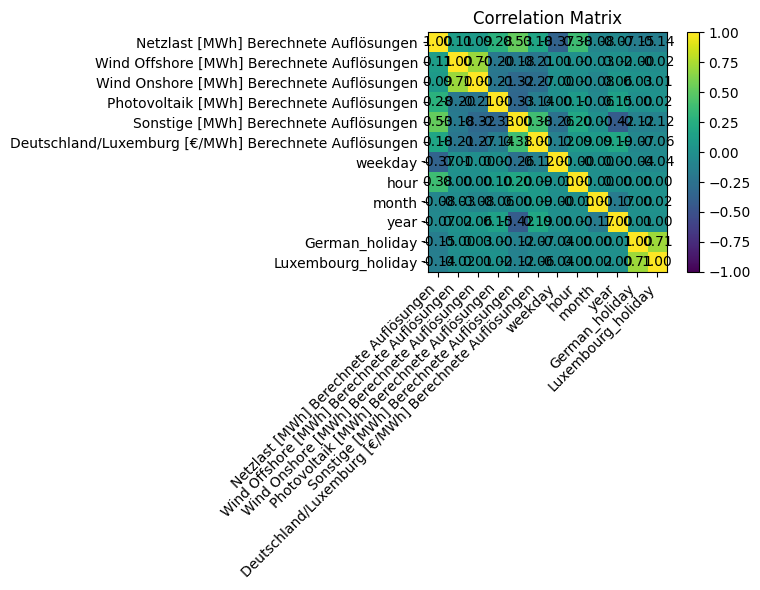

In [127]:
cols = df.columns
cols = cols.drop('Datum von')
corr_matrix = df[cols].corr()
corr_matrix


fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(corr_matrix, vmin=-1, vmax=1)

# Achsenbeschriftungen
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.index)))

ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.index)

# Werte in die Zellen schreiben
for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        ax.text(
            j, i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

# Colorbar
plt.colorbar(im, ax=ax)

ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

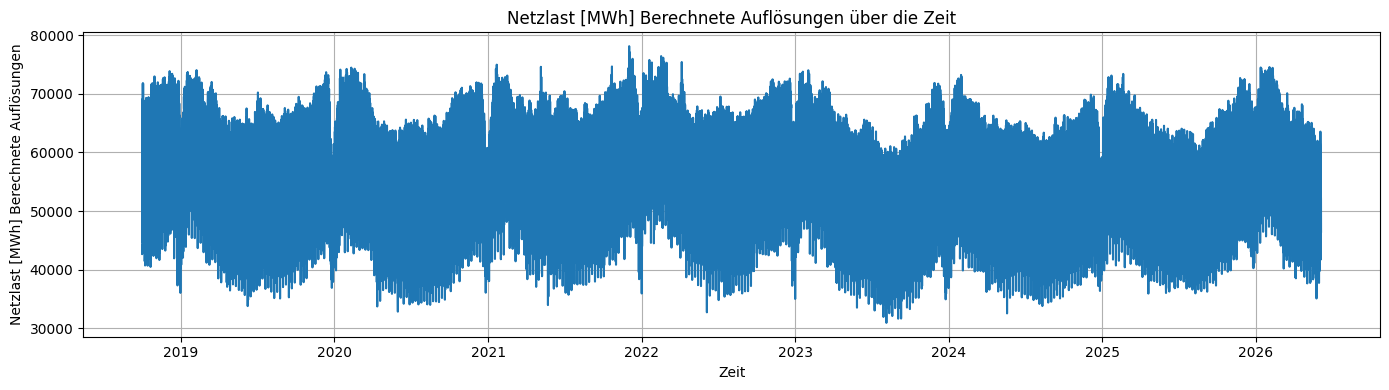

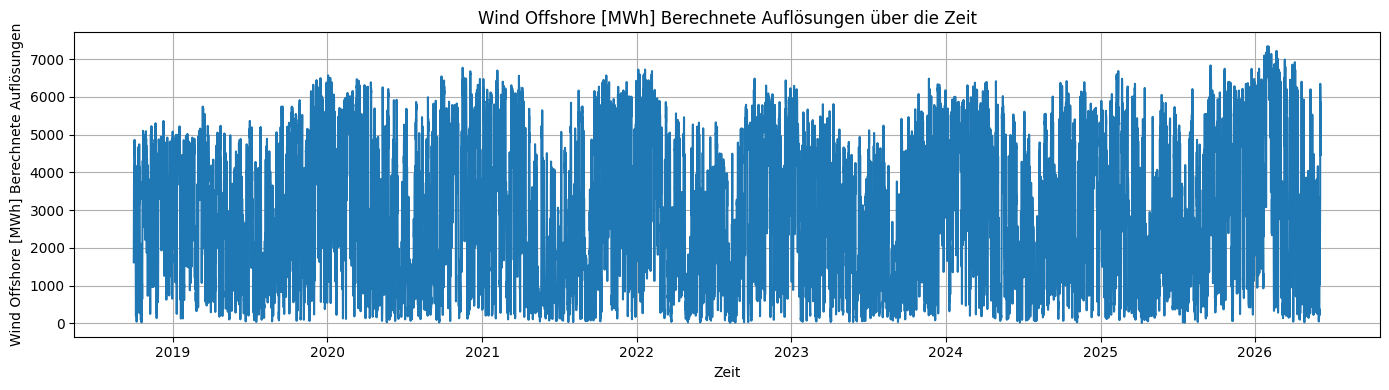

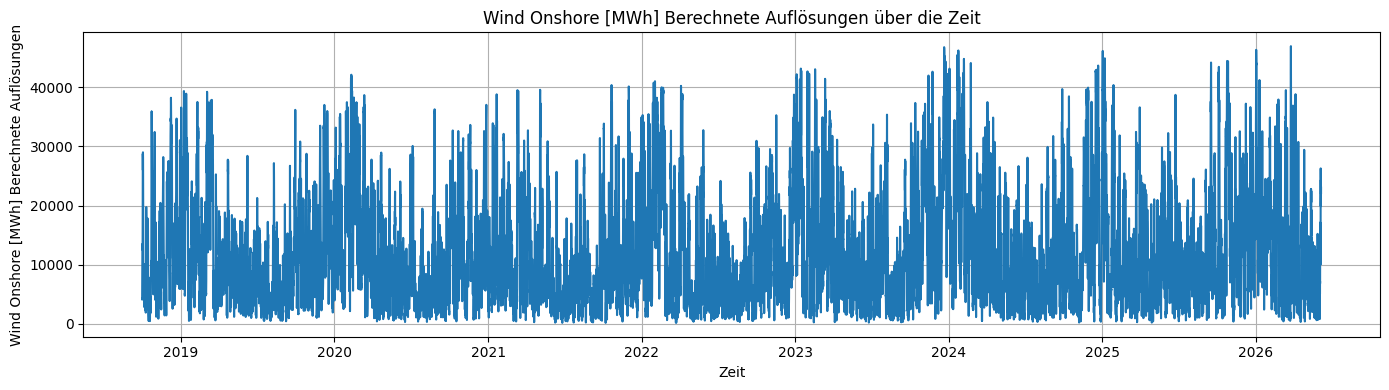

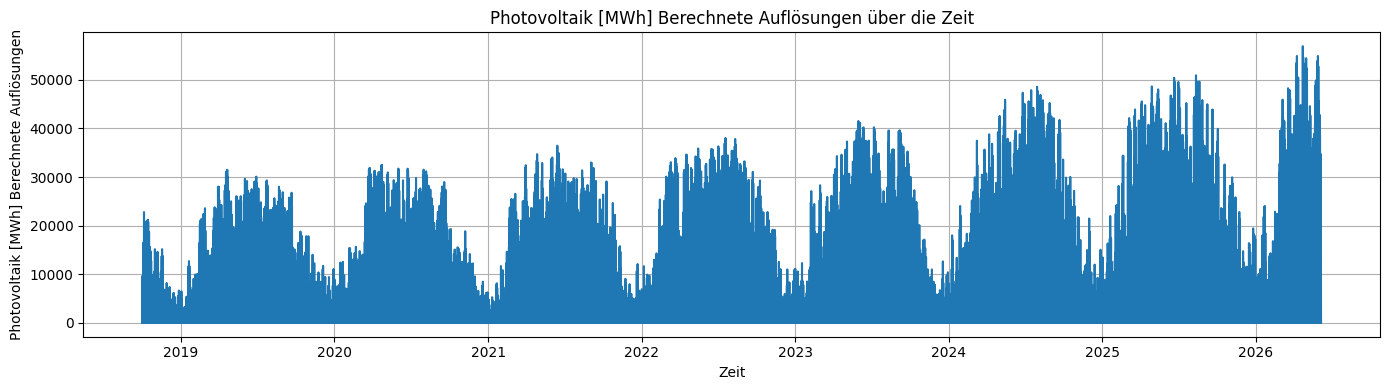

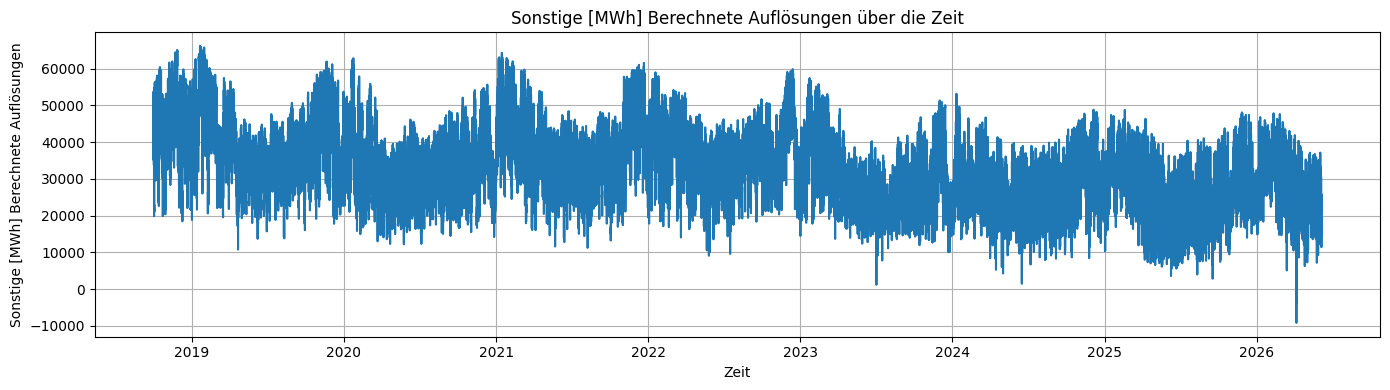

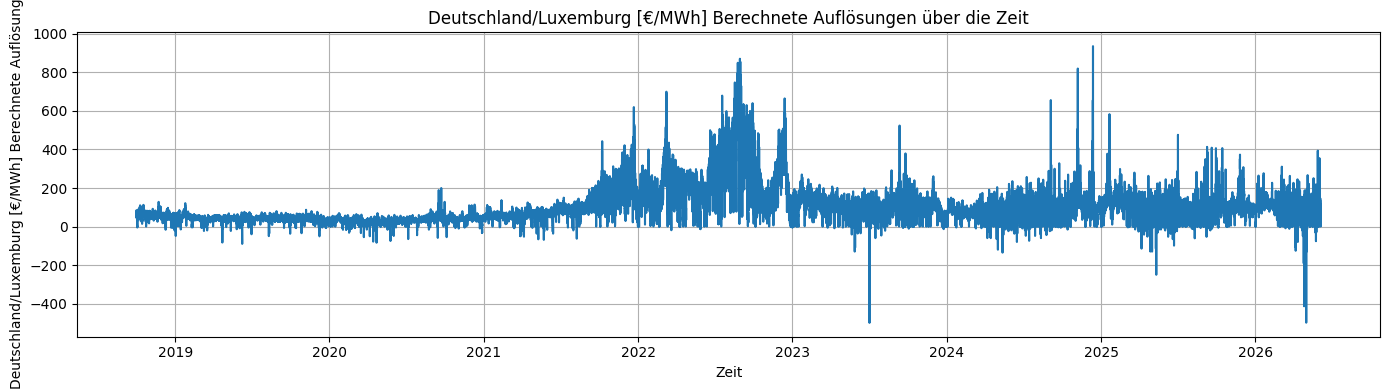

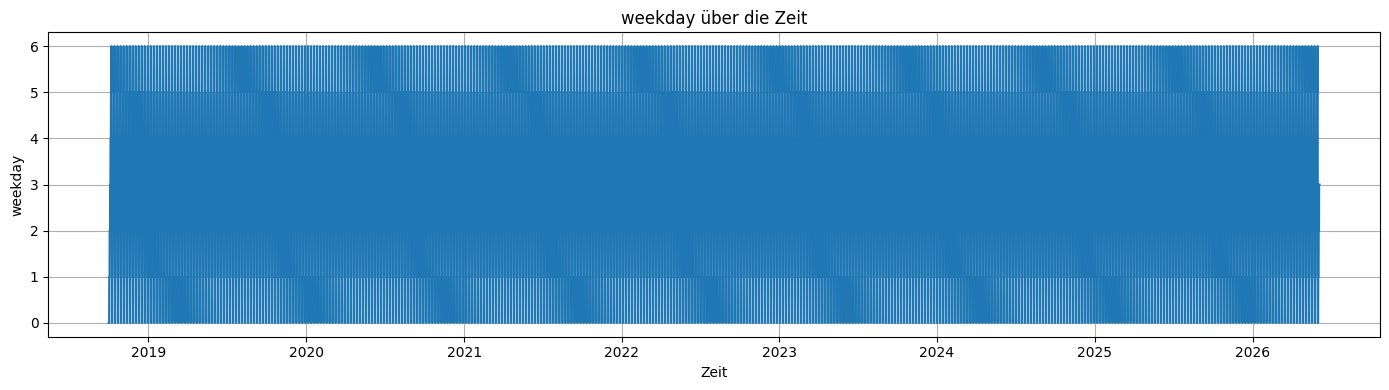

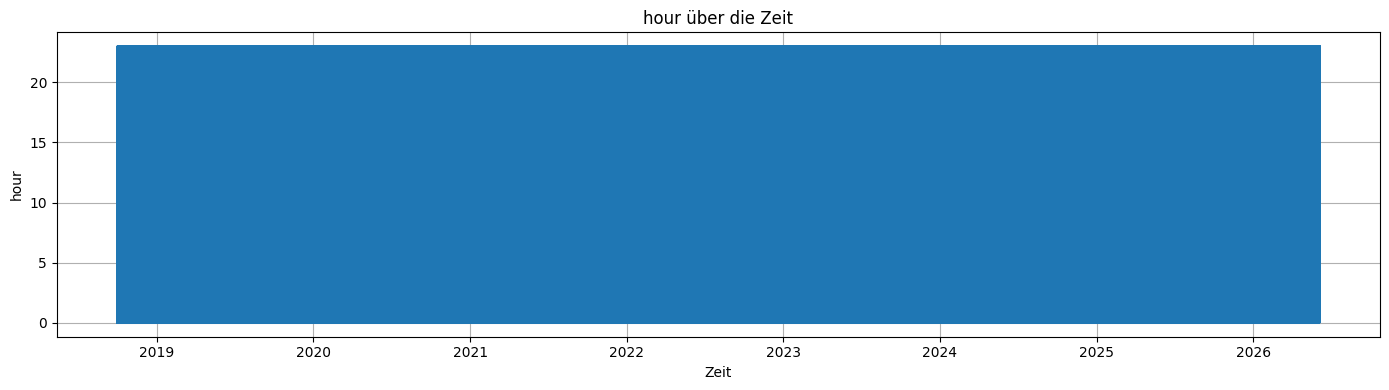

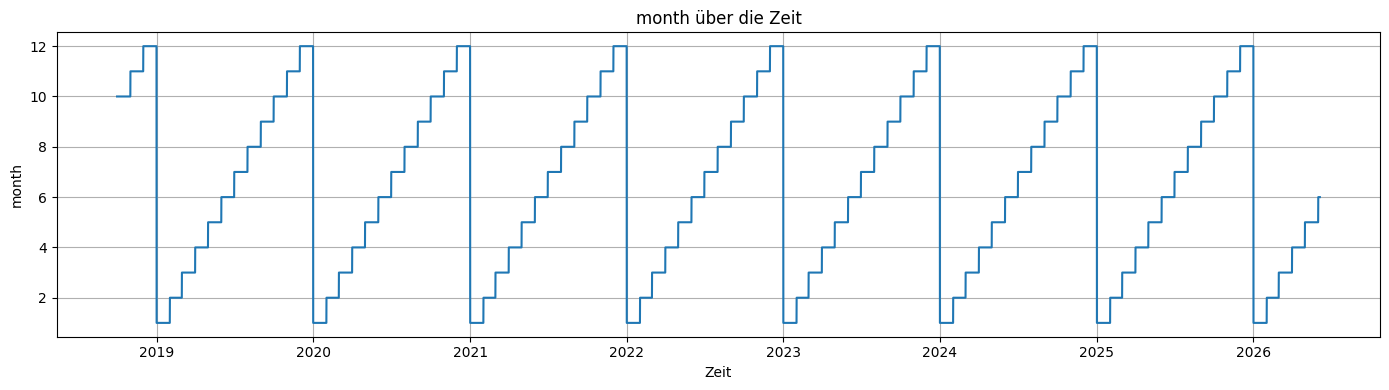

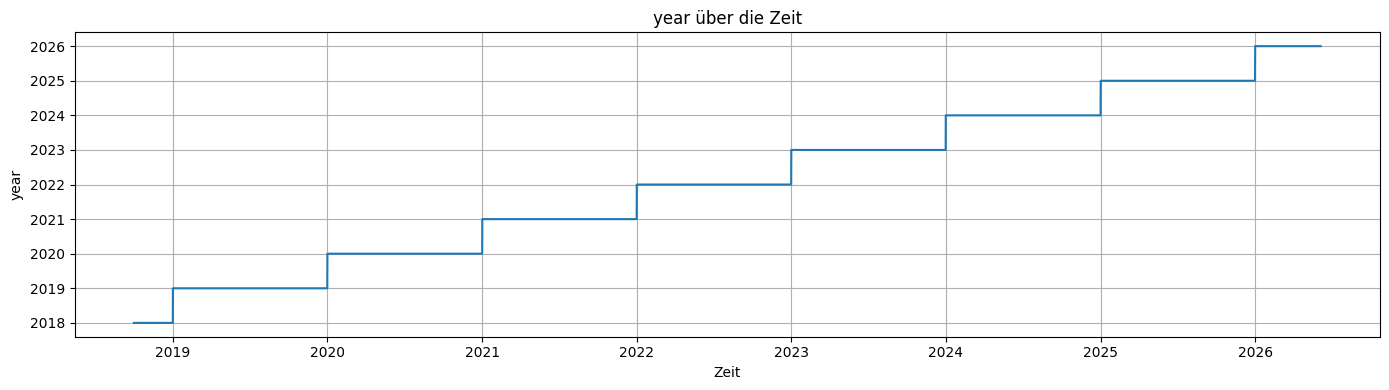

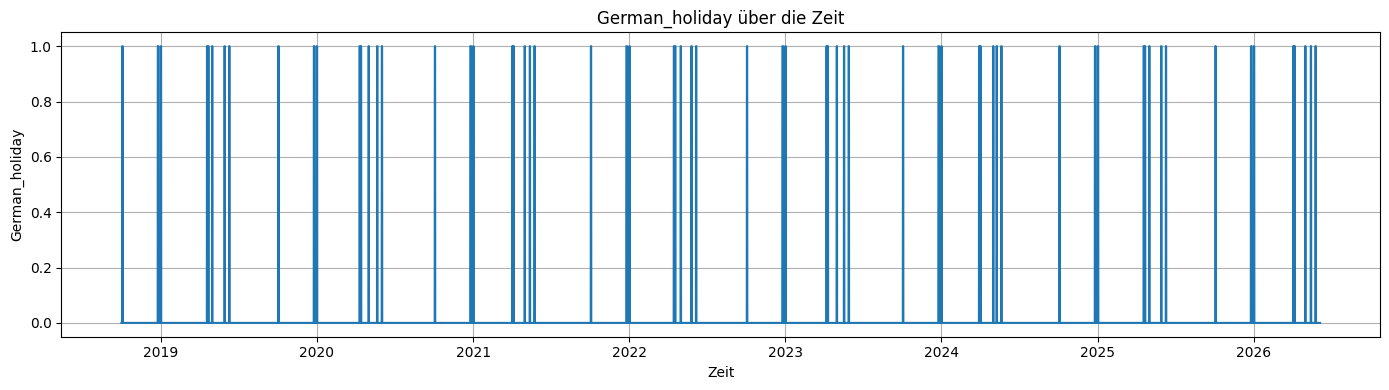

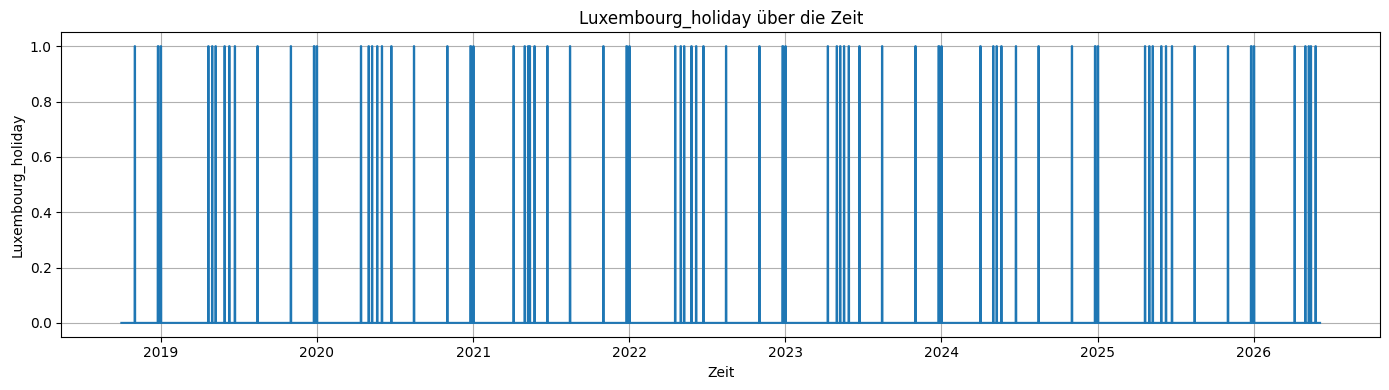

In [128]:
for col in cols:
    plt.figure(figsize=(14, 4))
    plt.plot(df["Datum von"], df[col])
    plt.title(f"{col} über die Zeit")
    plt.xlabel("Zeit")
    plt.ylabel(col)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

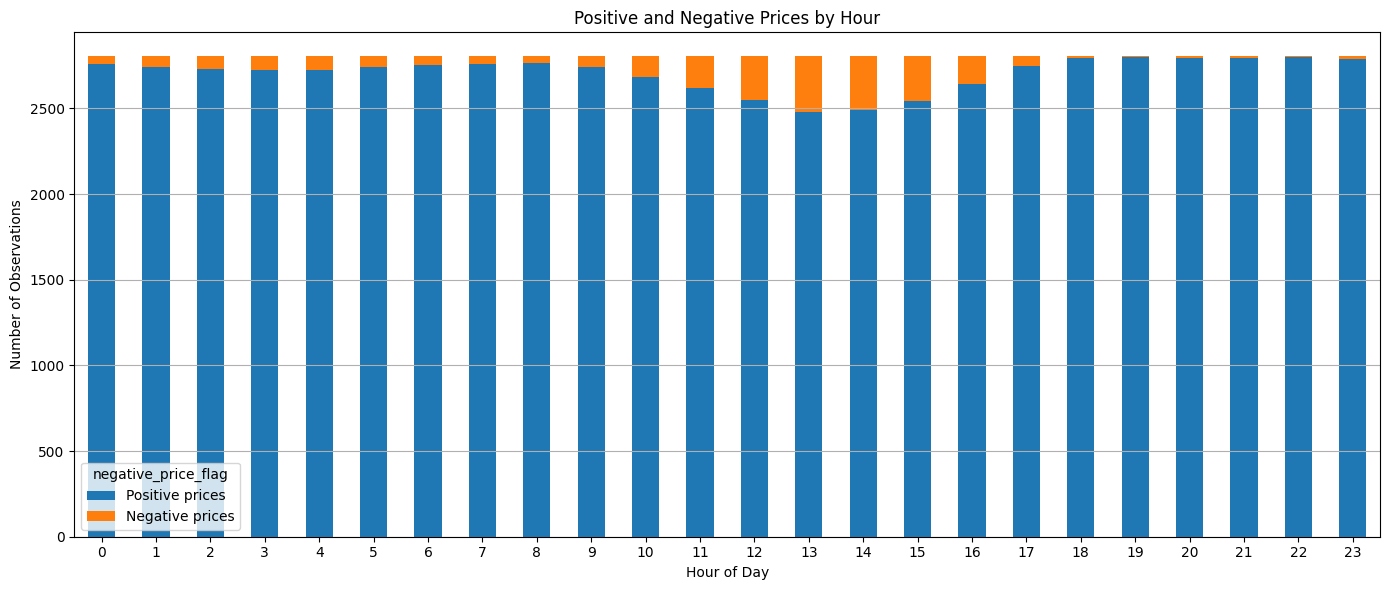

negative_price_flag,Positive prices,Negative prices
hour,,
0,2761,43
1,2744,60
2,2731,73
3,2723,81
4,2724,80
5,2744,60
6,2752,52
7,2758,46
8,2766,38


In [129]:
df["negative_price_flag"] = (df["Deutschland/Luxemburg [€/MWh] Berechnete Auflösungen"] < 0).astype(int)
df.groupby("negative_price_flag").count()["Datum von"]

neg_dist = df.groupby(["hour", "negative_price_flag"]).size().unstack()
neg_dist = neg_dist.rename(columns={
    0: "Positive prices",
    1: "Negative prices"
})
neg_dist[["Positive prices", "Negative prices"]].plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6)
)

plt.title("Positive and Negative Prices by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()
neg_dist

In [130]:
df.drop(columns=["negative_price_flag"], inplace=True)
df
hourly_dfs = {}

for hour in range(24):
    hourly_dfs[hour] = df[df["hour"] == hour].copy()

hourly_dfs[0].head()

,Datum von,Netzlast [MWh] Berechnete Auflösungen,Wind Offshore [MWh] Berechnete Auflösungen,Wind Onshore [MWh] Berechnete Auflösungen,Photovoltaik [MWh] Berechnete Auflösungen,Sonstige [MWh] Berechnete Auflösungen,Deutschland/Luxemburg [€/MWh] Berechnete Auflösungen,weekday,hour,month,year,German_holiday,Luxembourg_holiday
0,2018-10-01,44178.003337,1617.25,4242.00,0.0,38690.75,59.53,0,0,10,2018,False,False
24,2018-10-02,46408.000000,3384.50,12923.50,0.0,36528.00,45.10,1,0,10,2018,False,False
48,2018-10-03,49232.003828,4428.00,28958.75,0.0,20995.25,2.13,2,0,10,2018,True,False
72,2018-10-04,47087.113971,2344.25,9316.00,0.0,37429.75,53.24,3,0,10,2018,False,False
96,2018-10-05,46762.453366,4047.00,9043.00,0.0,39046.00,49.57,4,0,10,2018,False,False


Take away: A high class inbalance is apparent. This needs to be handled in the modelling part by balancing out the classes by using e.g. SMOTE or using a the correct evaluation metric (sensitivity instead of accuracy). Otherwise the modell will classify all observations as positive.

## 4. Planned Methods

Your mission **must** apply at least one technique from **each** of the three blocks below. Tick the ones you plan to use and briefly justify the choice.

### 4a. Causal Inference
- [x] Causal graph / DAG (DoWhy)
- [ ] Backdoor adjustment
- [ ] Instrumental variable
- [ ] Propensity score stratification
- [ ] Other: ___

*Justification:* Gaining a deep understanding of the inference, causalityand relationships of the different variables. This way we want to detect key drivers of negative day-ahead electricity prices.

### 4b. Supervised Learning
- [ ] Linear / Ridge / Lasso regression
- [ ] Logistic regression
- [ ] k-Nearest Neighbors
- [ ] Support Vector Machine
- [x] Decision Tree / Random Forest
- [x] Neural network (regression or classification)
- [ ] Other: ___

*Justification:* Starting with a decision tree we are beginning with one of the simplest and most explanable machine learning modells. As a next step we enhance the Modell with ensemble learning and use a random forest. As a last step we compare both mentioned modells against neural network as a state of the art modell.

### 4c. Unsupervised Learning / Generative Models
- [x] K-Means clustering
- [ ] Hierarchical clustering
- [ ] Variational autoencoder
- [ ] GAN
- [x] Other: DB-Scan (to be evaluated)

*Justification:* Depending on the data structures we are aming to find non-hierarchical and indipendent clusters with DB-Scan and/or K-Means.


## 5. Evaluation Strategy

*How will you know if your mission succeeded? Describe:*

Unsupervised Learning
- Usnig silhouette score to evaluate how well observations fit into their assigned cluster
- Using elbow method to evaluate whether additional clusters reduce within-cluster variance
- Different methods of data visualization to put the results in context

Supervised Learning
- Comparing the modell against random classification
- Using accuracy to detect the share of correct classifications
- Using the evaluation metric of sensivity to specificly identify negative prices
- Comparing Neural Network with Random Forrest
- Different methods of data visualization to put the results in context
- Baseline Modell: Naive 
- RMSE


## 6. Work Plan

| Step | Owner | Description |
|------|-------|-------------|
| 1 | Tim und Lennart | Data collection & cleaning |
| 2 | Lennart | Feature Construction |
| 3 | Tim | Causal inference block |
| 4 | Tim und Lennart| Unsupervised learning block |
| 5 | Tim und Lennart| Supervised learning block |
| 6 | Tim und Lennart | Synthesis & write-up |


## Pending Questions

What kind of presentation is needed (length and format)?

Causal 

Do we use only the original features for causal inference or also the constructed ones?



---
## 7. Results *(complete for final submission)*


### 7a. Causal Inference

In [131]:
# Causal inference analysis

### 7b. Supervised Learning

In [ ]:
df_model = hourly_dfs[12].copy()

# Nach Zeit sortieren
df_model = df_model.sort_values("Datum von").reset_index(drop=True)

# Zielvariable: Day-Ahead-Preis
target_col = "Deutschland/Luxemburg [€/MWh] Berechnete Auflösungen"

# Features
feature_cols = [
    'Wind Offshore [MWh] Berechnete Auflösungen',
    'Wind Onshore [MWh] Berechnete Auflösungen',
    'Photovoltaik [MWh] Berechnete Auflösungen',
    'Sonstige [MWh] Berechnete Auflösungen',
    "Netzlast [MWh] Berechnete Auflösungen",
    'weekday',
    'month',
    'year',
    'German_holiday',
    'Luxembourg_holiday'
]

# Nur relevante Spalten behalten und fehlende Werte entfernen
df_model = df_model[["Datum von"] + feature_cols + [target_col]].dropna()

all_predictions = []
all_feature_importances = []

# Erster Testtag: ein Jahr nach erstem Datum
first_test_day = df_model["Datum von"].min() + pd.DateOffset(years=1)

# Letzter möglicher Testtag
last_test_day = pd.to_datetime("2020-10-01 00:00:00")

current_test_day = first_test_day

while current_test_day <= last_test_day:
    
    # Trainingszeitraum: letztes Jahr
    train_start = current_test_day - pd.DateOffset(years=1)
    train_end = current_test_day
    
    # Testzeitraum: nächster Tag
    test_start = current_test_day
    test_end = current_test_day + pd.DateOffset(days=1)
    
    train = df_model[
        (df_model["Datum von"] >= train_start) &
        (df_model["Datum von"] < train_end)
    ]
    
    test = df_model[
        (df_model["Datum von"] >= test_start) &
        (df_model["Datum von"] < test_end)
    ]
    
    # Falls zu wenig Daten vorhanden sind, überspringen
    if len(train) == 0 or len(test) == 0:
        current_test_day += pd.DateOffset(days=1)
        continue
    
    X_train = train[feature_cols]
    y_train = train[target_col]
    
    X_test = test[feature_cols]
    y_test = test[target_col]
    
    # Modelle definieren
    models = {
        "Random Forest": RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            min_samples_leaf=2
        ),
        
        "Decision Tree": DecisionTreeRegressor(
            random_state=42,
            min_samples_leaf=5
        ),
        
        # NN aus Keras 
        "Simple Neural Network": Pipeline(steps=[
            ("scaler", StandardScaler()),
            ("model", MLPRegressor(
                hidden_layer_sizes=(32, 16),
                activation="relu",
                solver="adam",
                max_iter=1000,
                random_state=42
            ))
        ])
    }
    
    # Alle ML-Modelle trainieren, vorhersagen und Feature Importance speichern
    for model_name, model in models.items():
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        # Ergebnisse speichern
        pred_df = pd.DataFrame({
            "Datum von": test["Datum von"].values,
            "model": model_name,
            "y_true": y_test.values,
            "y_pred": y_pred,
            "train_start": train_start,
            "train_end": train_end,
            "test_day": test_start,
            "train_rows": len(train),
            "test_rows": len(test)
        })
        
        all_predictions.append(pred_df)
        
        # -----------------------------
        # Feature Importance
        # -----------------------------
        
        if model_name in ["Random Forest", "Decision Tree"]:
            
            importance_values = model.feature_importances_
            
            fi_df = pd.DataFrame({
                "test_day": test_start,
                "model": model_name,
                "feature": feature_cols,
                "importance": importance_values,
                "importance_type": "tree_feature_importance"
            })
            
            all_feature_importances.append(fi_df)
        
        
        elif model_name == "Simple Neural Network":
            
            # Für NN gibt es keine direkte Feature Importance.
            # Deshalb Permutation Importance auf dem Trainingsfenster.
            perm = permutation_importance(
                model,
                X_train,
                y_train,
                n_repeats=10,
                random_state=42,
                scoring="neg_mean_absolute_error",
                n_jobs=-1
            )
            
            fi_df = pd.DataFrame({
                "test_day": test_start,
                "model": model_name,
                "feature": feature_cols,
                "importance": perm.importances_mean,
                "importance_std": perm.importances_std,
                "importance_type": "permutation_importance_train"
            })
            
            all_feature_importances.append(fi_df)
    
    # Naive Forecast: letzter bekannter Preis im Trainingsfenster
    naive_prediction = y_train.iloc[-1]
    y_pred_naive = np.repeat(naive_prediction, len(y_test))
    
    pred_df_naive = pd.DataFrame({
        "Datum von": test["Datum von"].values,
        "model": "Naive",
        "y_true": y_test.values,
        "y_pred": y_pred_naive,
        "train_start": train_start,
        "train_end": train_end,
        "test_day": test_start,
        "train_rows": len(train),
        "test_rows": len(test)
    })
    
    all_predictions.append(pred_df_naive)
    
    # Naive hat keine Feature Importance, da keine Features verwendet werden
    fi_naive = pd.DataFrame({
        "test_day": test_start,
        "model": "Naive",
        "feature": feature_cols,
        "importance": np.nan,
        "importance_type": "not_applicable"
    })
    
    all_feature_importances.append(fi_naive)
    
    # Einen Tag weiterrollen
    current_test_day += pd.DateOffset(days=1)

# Alle Tagesprognosen zusammenführen
rolling_predictions = pd.concat(all_predictions, ignore_index=True)

# Alle Feature Importances zusammenführen
feature_importances = pd.concat(all_feature_importances, ignore_index=True)

rolling_predictions

/Users/lennart/coding/DAI/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/lennart/coding/DAI/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/lennart/coding/DAI/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/lennart/coding/DAI/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.wa

,Datum von,model,y_true,y_pred,train_start,train_end,test_day,train_rows,test_rows
0,2019-10-01 12:00:00,Random Forest,42.17,43.340631,2018-10-01 12:00:00,2019-10-01 12:00:00,2019-10-01 12:00:00,365,1
1,2019-10-01 12:00:00,Decision Tree,42.17,45.872000,2018-10-01 12:00:00,2019-10-01 12:00:00,2019-10-01 12:00:00,365,1
2,2019-10-01 12:00:00,Lasso,42.17,37.171625,2018-10-01 12:00:00,2019-10-01 12:00:00,2019-10-01 12:00:00,365,1
3,2019-10-01 12:00:00,Simple Neural Network,42.17,33.281915,2018-10-01 12:00:00,2019-10-01 12:00:00,2019-10-01 12:00:00,365,1
4,2019-10-01 12:00:00,Naive,42.17,11.820000,2018-10-01 12:00:00,2019-10-01 12:00:00,2019-10-01 12:00:00,365,1
...,...,...,...,...,...,...,...,...,...
1825,2020-09-30 12:00:00,Random Forest,49.17,50.954821,2019-09-30 12:00:00,2020-09-30 12:00:00,2020-09-30 12:00:00,366,1
1826,2020-09-30 12:00:00,Decision Tree,49.17,54.436000,2019-09-30 12:00:00,2020-09-30 12:00:00,2020-09-30 12:00:00,366,1
1827,2020-09-30 12:00:00,Lasso,49.17,51.434713,2019-09-30 12:00:00,2020-09-30 12:00:00,2020-09-30 12:00:00,366,1
1828,2020-09-30 12:00:00,Simple Neural Network,49.17,50.363985,2019-09-30 12:00:00,2020-09-30 12:00:00,2020-09-30 12:00:00,366,1


In [133]:
avg_feature_importance = (
    feature_importances
    .dropna(subset=["importance"])
    .groupby(["model", "feature"], as_index=False)
    .agg(
        mean_importance=("importance", "mean"),
        std_importance=("importance", "std")
    )
    .sort_values(["model", "mean_importance"], ascending=[True, False])
)

avg_feature_importance

,model,feature,mean_importance,std_importance
4,Decision Tree,Sonstige [MWh] Berechnete Auflösungen,0.862395,0.016019
6,Decision Tree,Wind Onshore [MWh] Berechnete Auflösungen,0.045737,0.022839
5,Decision Tree,Wind Offshore [MWh] Berechnete Auflösungen,0.035685,0.023970
7,Decision Tree,month,0.017982,0.011588
3,Decision Tree,Photovoltaik [MWh] Berechnete Auflösungen,0.015042,0.007074
9,Decision Tree,year,0.013233,0.015393
2,Decision Tree,Netzlast [MWh] Berechnete Auflösungen,0.008814,0.003970
8,Decision Tree,weekday,0.001112,0.001371
0,Decision Tree,German_holiday,0.000000,0.000000
1,Decision Tree,Luxembourg_holiday,0.000000,0.000000


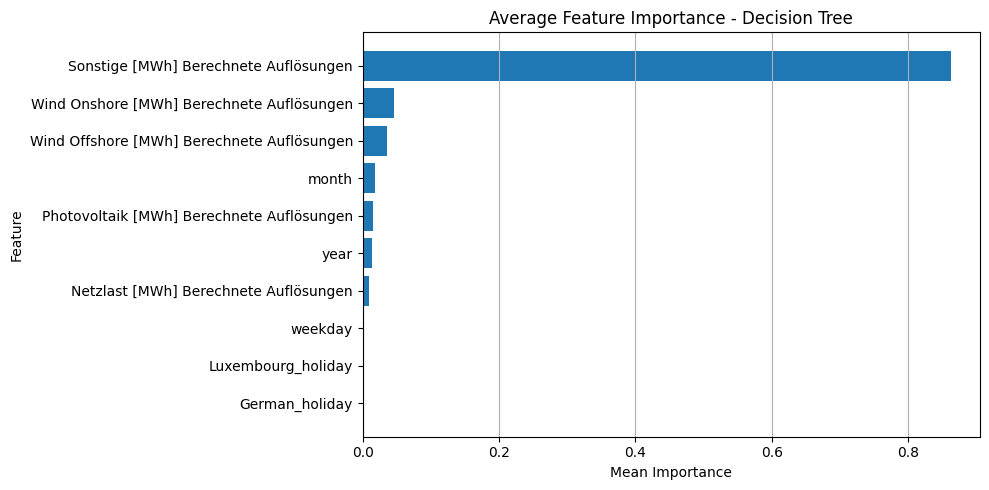

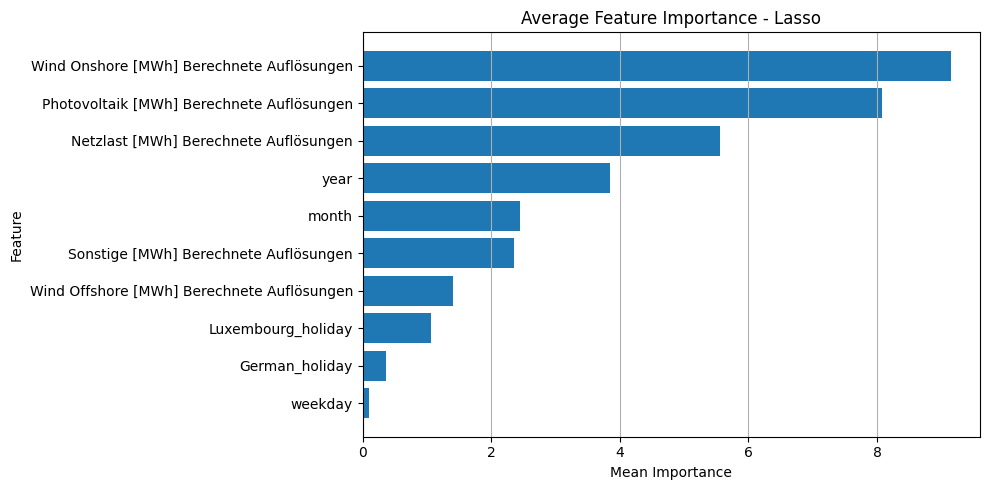

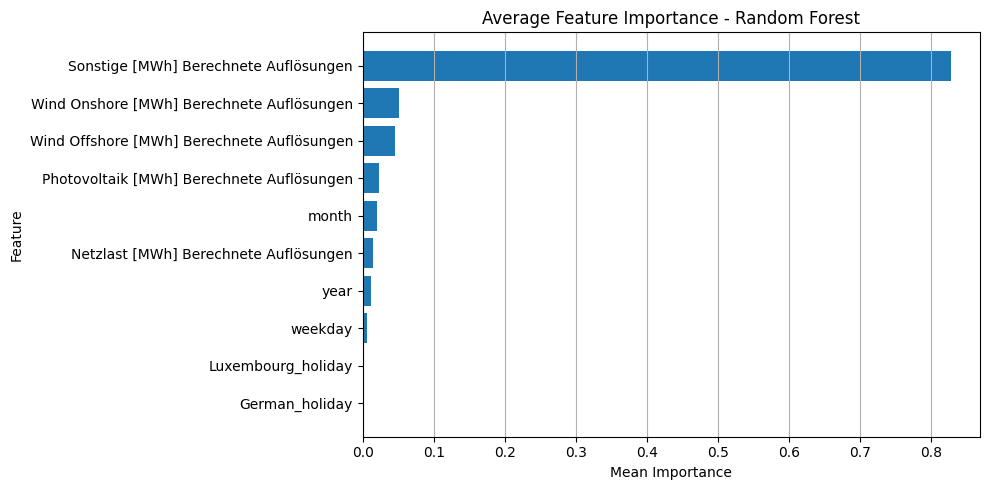

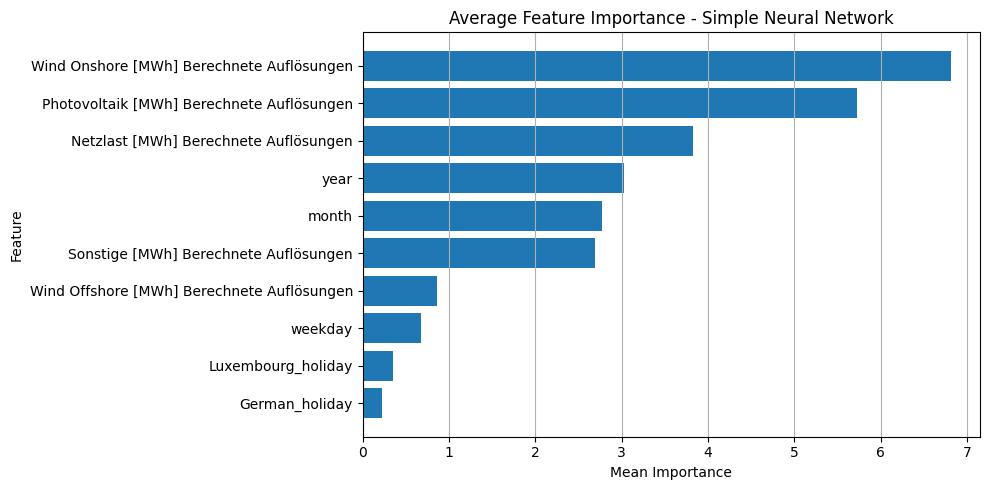

In [134]:
import matplotlib.pyplot as plt

for model_name in avg_feature_importance["model"].unique():
    
    temp = (
        avg_feature_importance[avg_feature_importance["model"] == model_name]
        .sort_values("mean_importance", ascending=True)
    )
    
    plt.figure(figsize=(10, 5))
    
    plt.barh(
        temp["feature"],
        temp["mean_importance"]
    )
    
    plt.title(f"Average Feature Importance - {model_name}")
    plt.xlabel("Mean Importance")
    plt.ylabel("Feature")
    plt.grid(axis="x")
    plt.tight_layout()
    plt.show()

In [135]:
model_performance = (
    rolling_predictions
    .groupby("model")
    .apply(lambda x: pd.Series({
        "MAE": mean_absolute_error(x["y_true"], x["y_pred"]),
        "RMSE": np.sqrt(mean_squared_error(x["y_true"], x["y_pred"])),
        "R2": r2_score(x["y_true"], x["y_pred"]),
        "Observations": len(x)
    }))
    .reset_index()
    .sort_values("MAE")
)

model_performance

,model,MAE,RMSE,R2,Observations
3,Random Forest,4.927867,7.198119,0.844582,366.0
4,Simple Neural Network,5.556464,8.837840,0.765709,366.0
0,Decision Tree,6.283168,9.742777,0.715273,366.0
1,Lasso,6.752004,9.870109,0.707782,366.0
2,Naive,11.490191,18.150468,0.011815,366.0


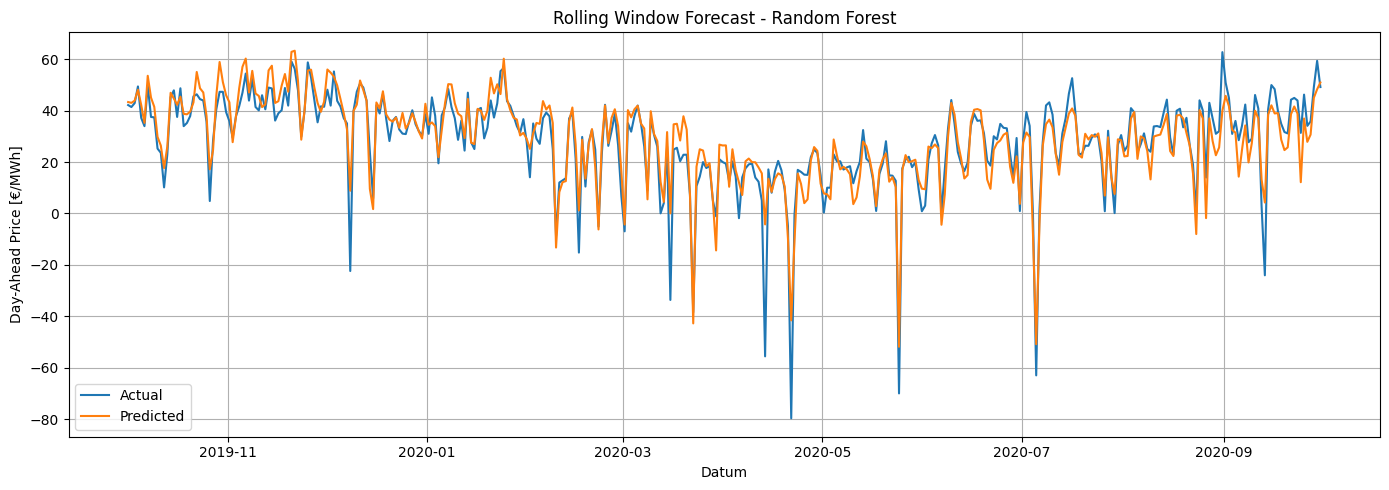

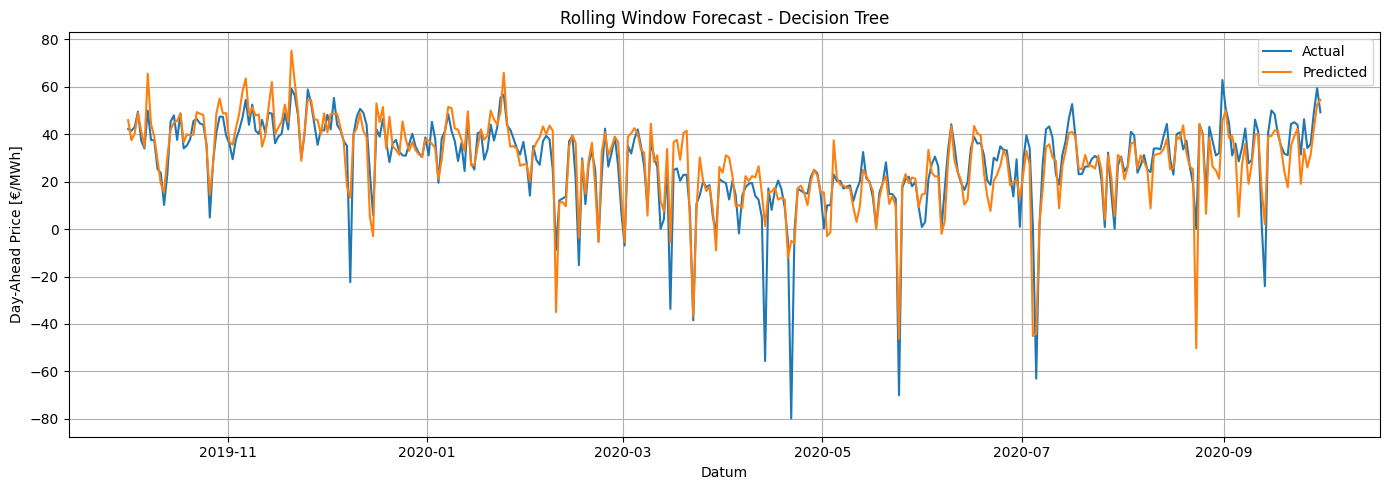

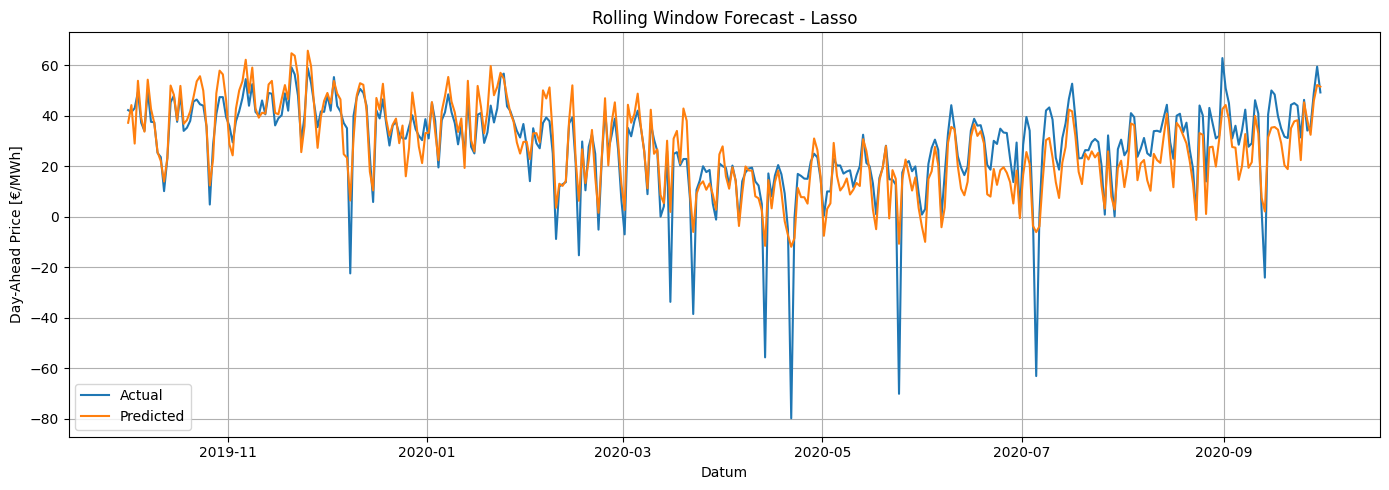

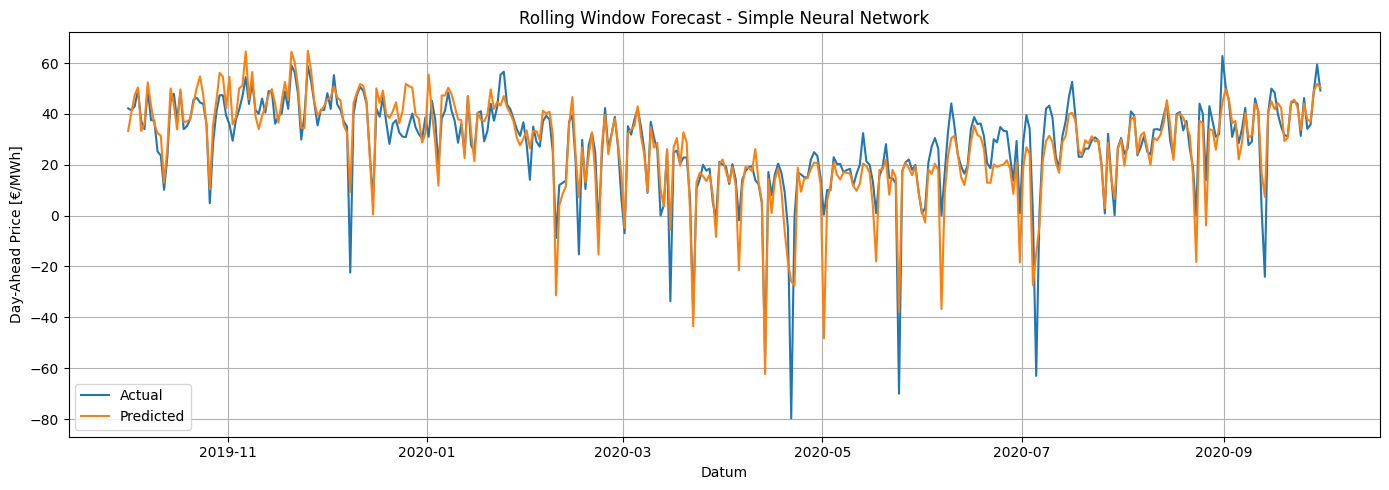

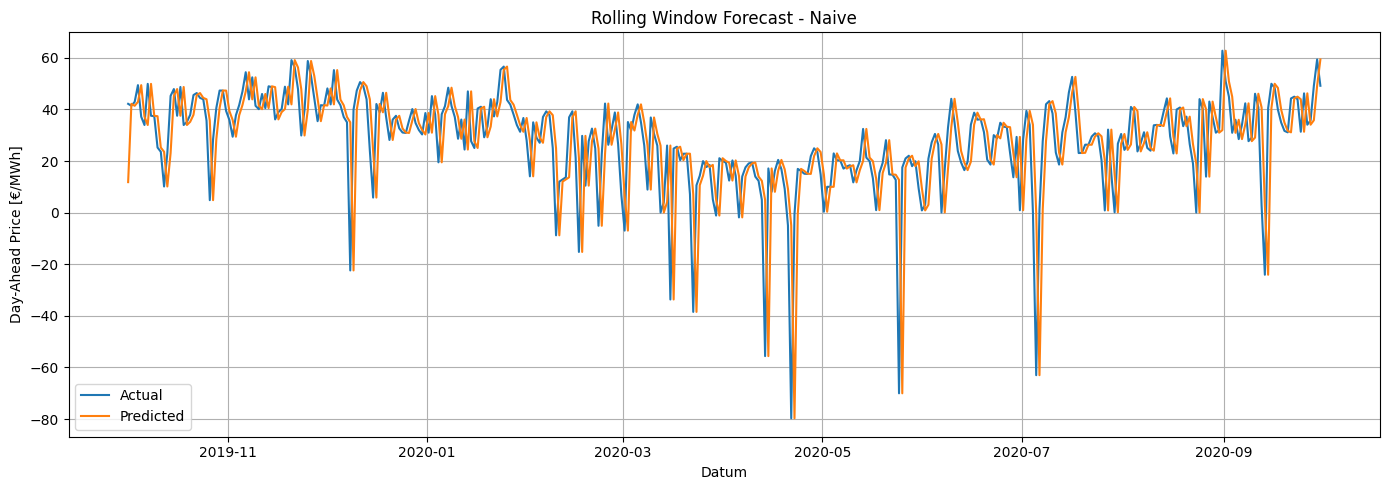

In [136]:
import matplotlib.pyplot as plt

for model_name in rolling_predictions["model"].unique():
    
    temp = rolling_predictions[rolling_predictions["model"] == model_name]
    
    plt.figure(figsize=(14, 5))
    
    plt.plot(
        temp["Datum von"],
        temp["y_true"],
        label="Actual"
    )
    
    plt.plot(
        temp["Datum von"],
        temp["y_pred"],
        label="Predicted"
    )
    
    plt.title(f"Rolling Window Forecast - {model_name}")
    plt.xlabel("Datum")
    plt.ylabel("Day-Ahead Price [€/MWh]")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

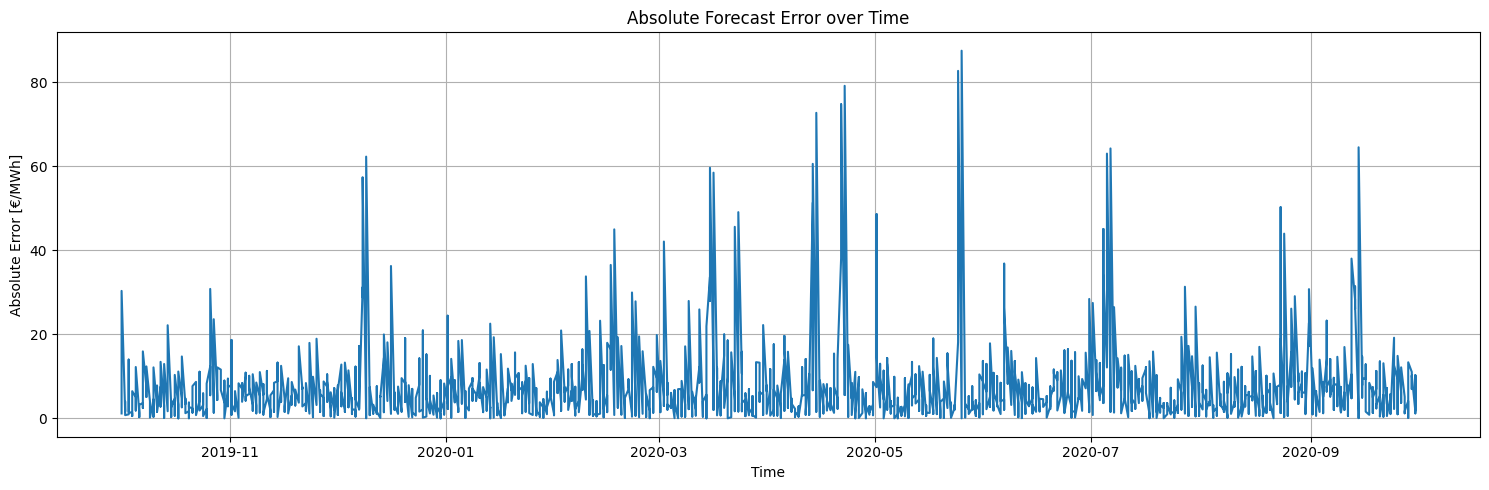

In [137]:
rolling_predictions["error"] = (
    rolling_predictions["y_true"] - rolling_predictions["y_pred"]
)

rolling_predictions["absolute_error"] = rolling_predictions["error"].abs()

plt.figure(figsize=(15, 5))

plt.plot(
    rolling_predictions["Datum von"],
    rolling_predictions["absolute_error"]
)

plt.title("Absolute Forecast Error over Time")
plt.xlabel("Time")
plt.ylabel("Absolute Error [€/MWh]")
plt.grid(True)
plt.tight_layout()
plt.show()

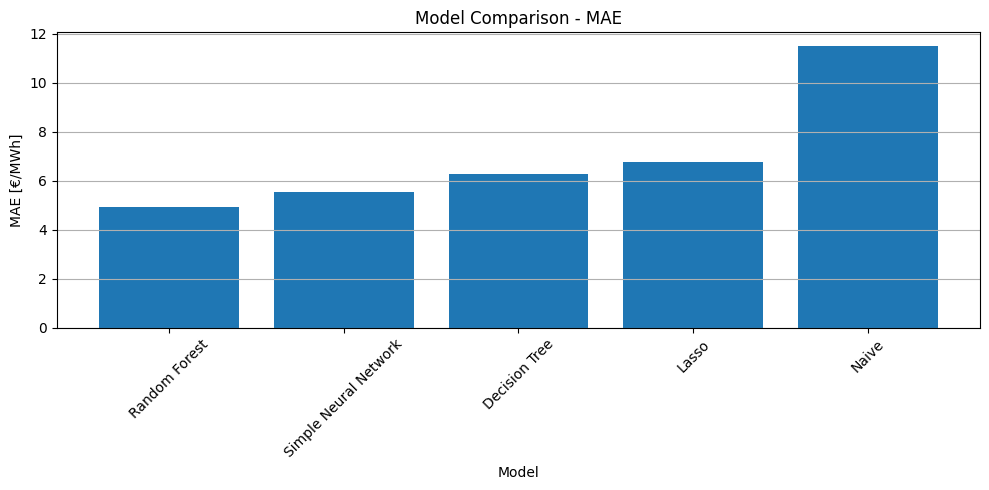

In [138]:
plt.figure(figsize=(10, 5))

plt.bar(
    model_performance["model"],
    model_performance["MAE"]
)

plt.title("Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("MAE [€/MWh]")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### 7c. Unsupervised / Generative

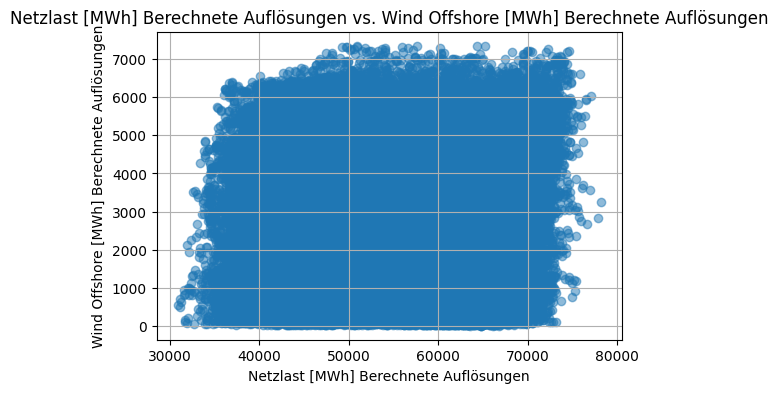

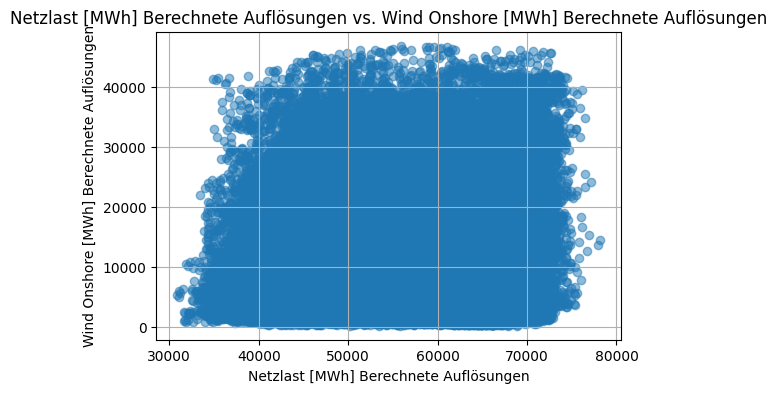

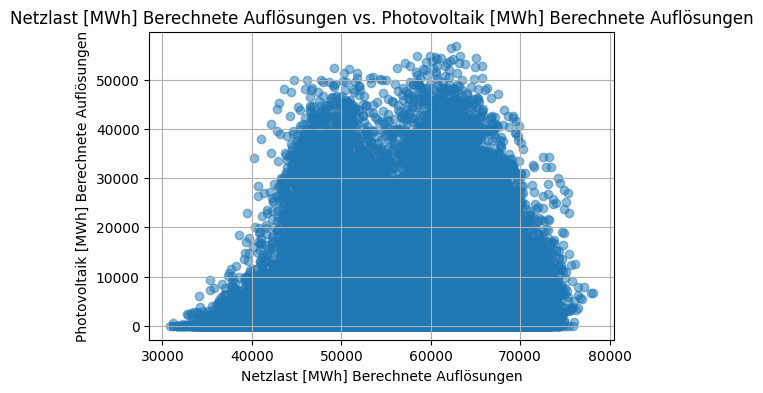

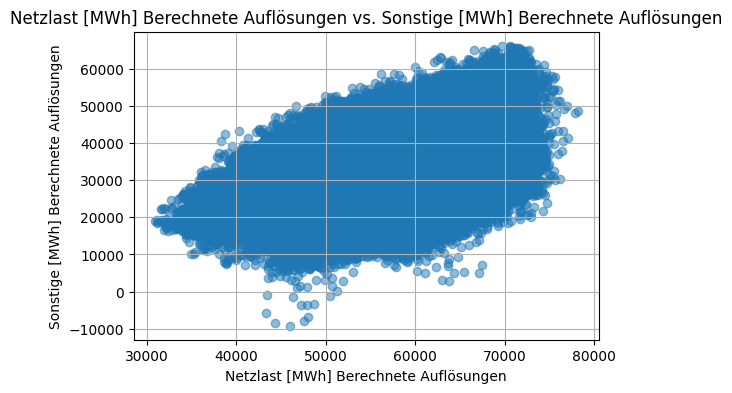

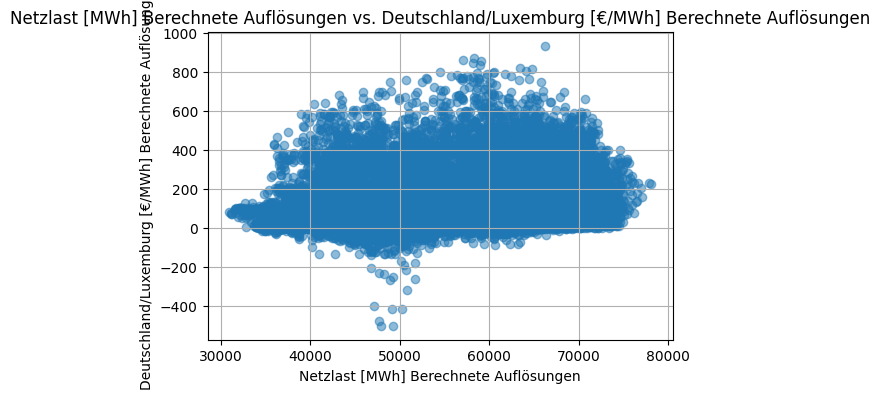

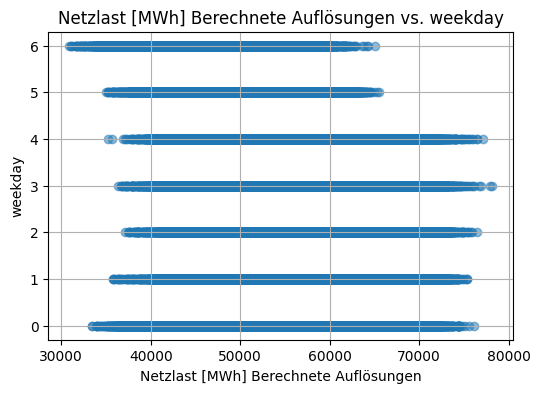

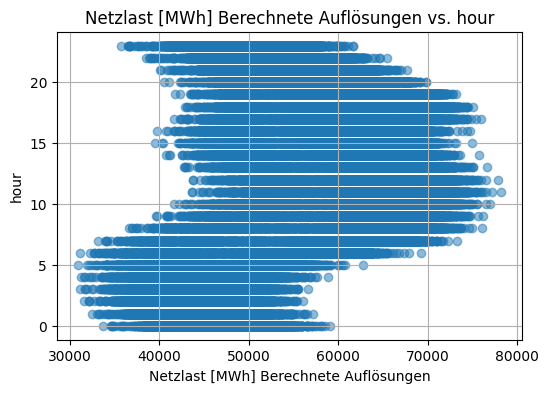

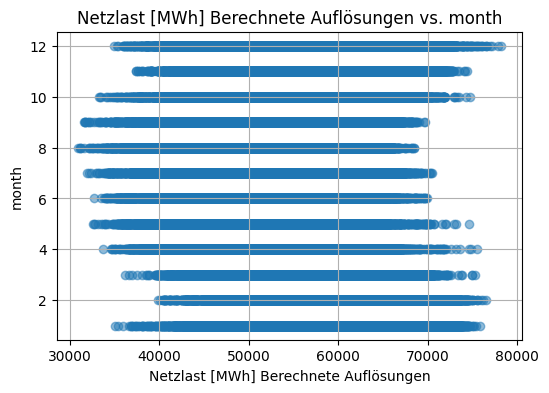

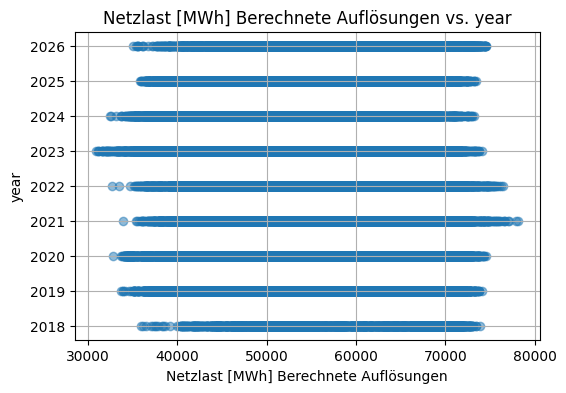

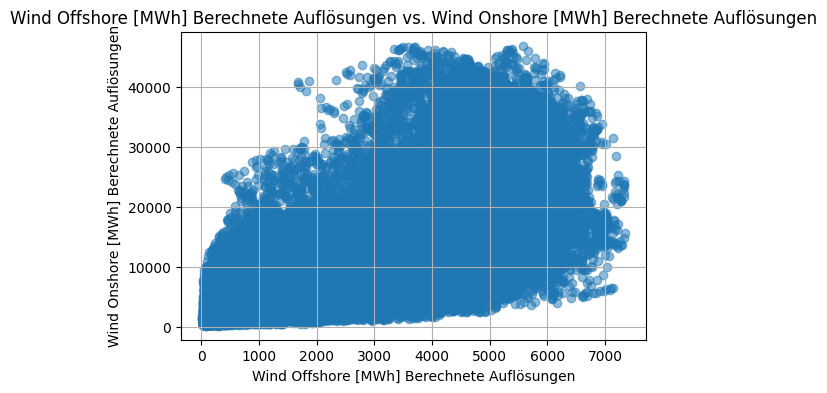

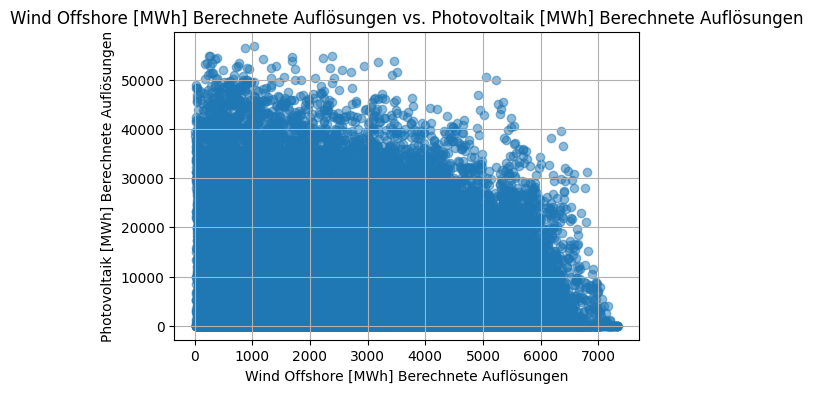

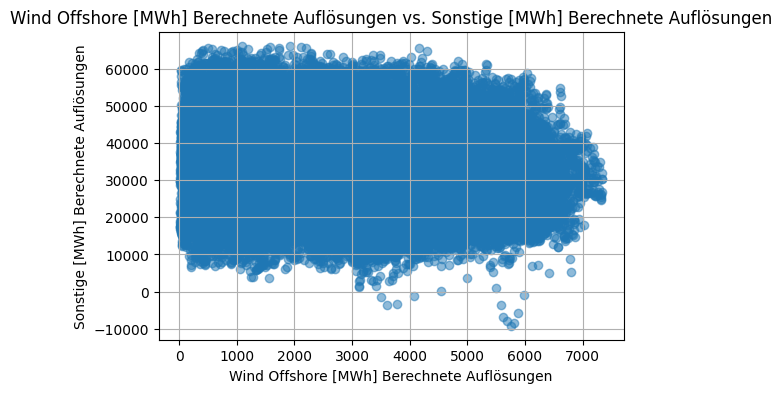

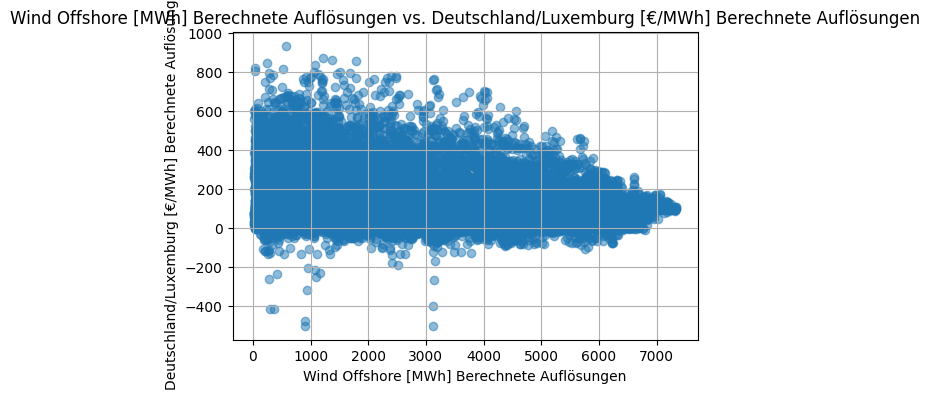

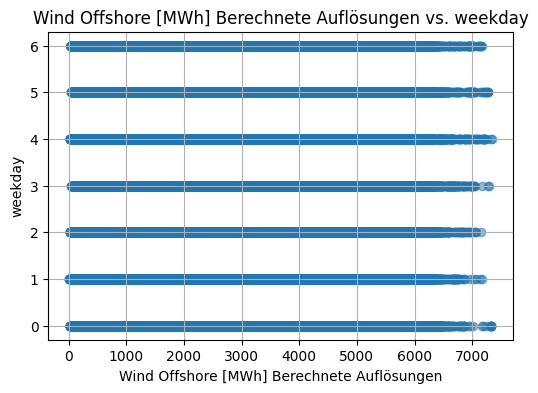

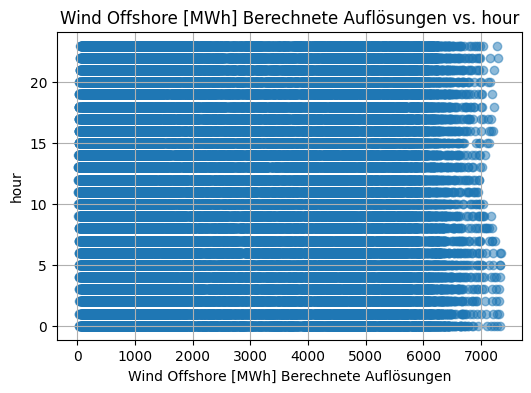

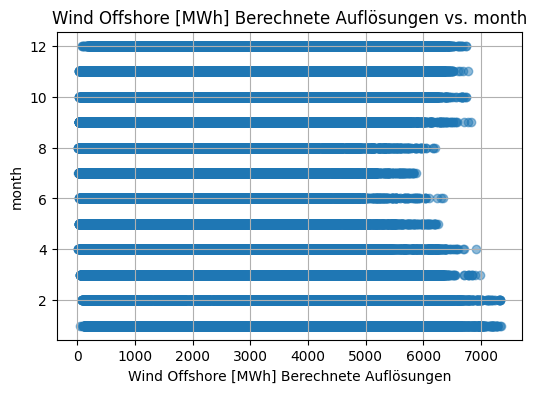

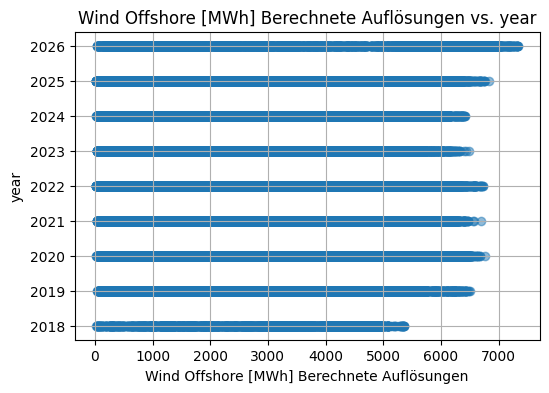

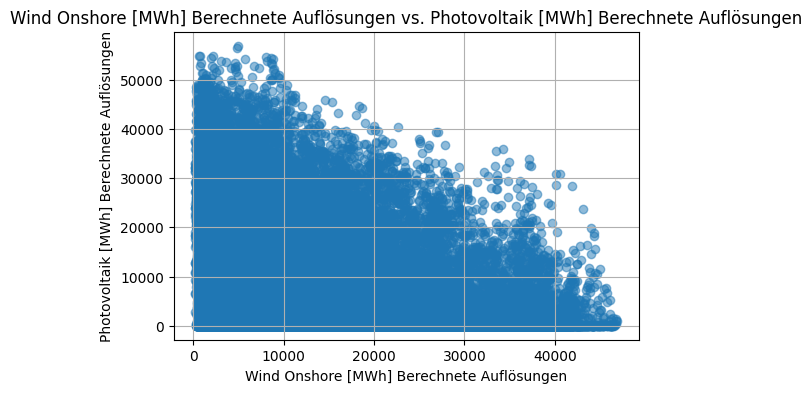

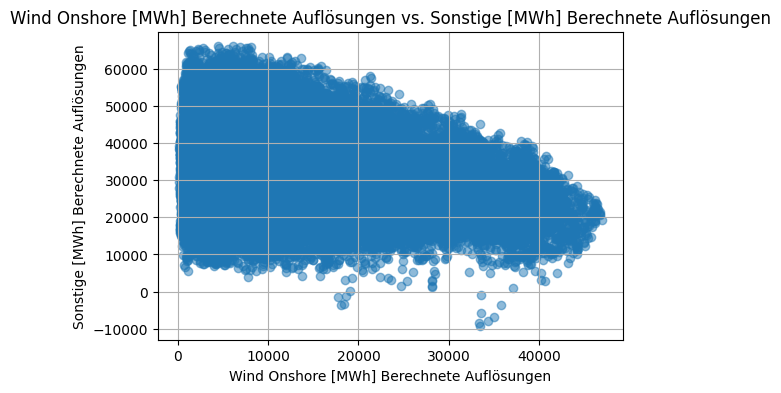

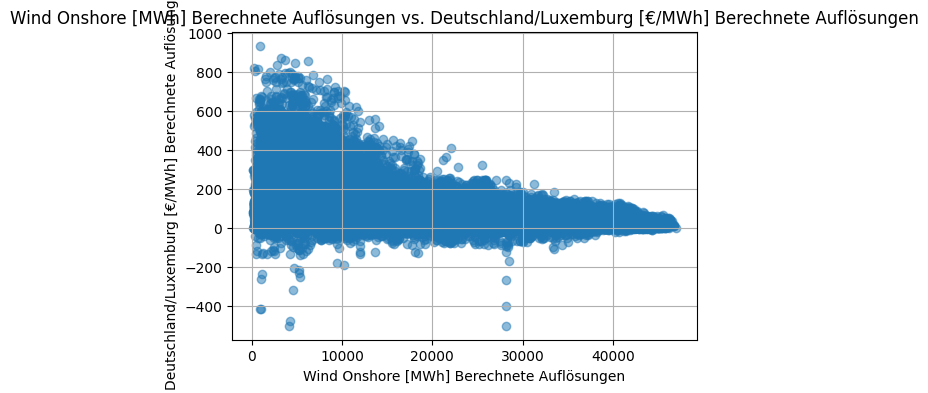

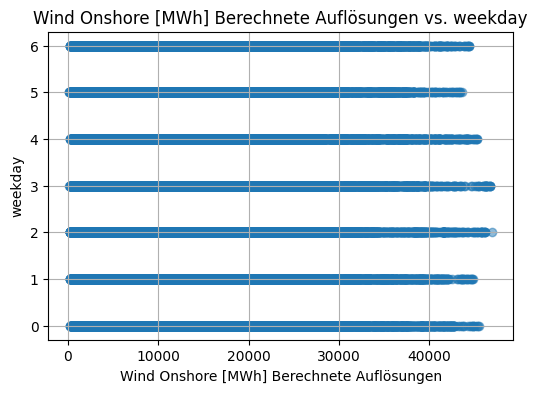

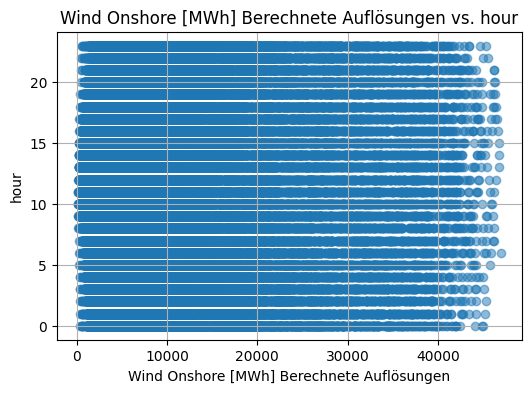

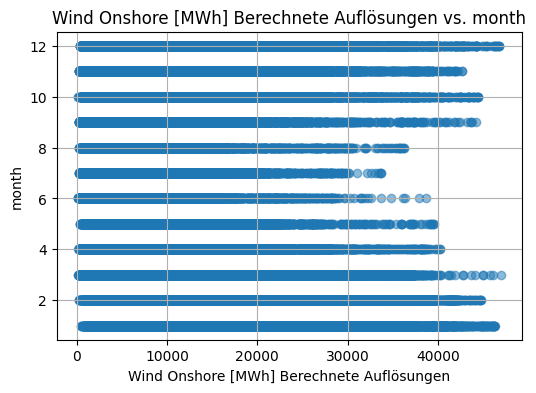

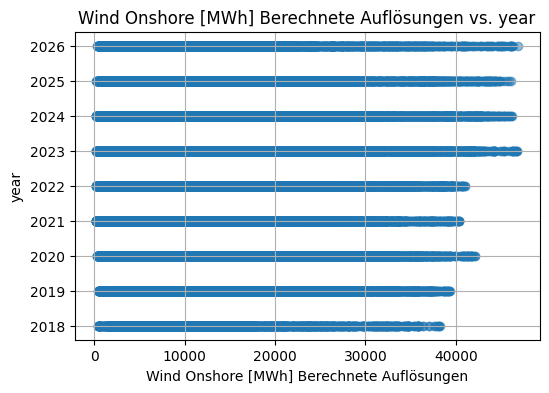

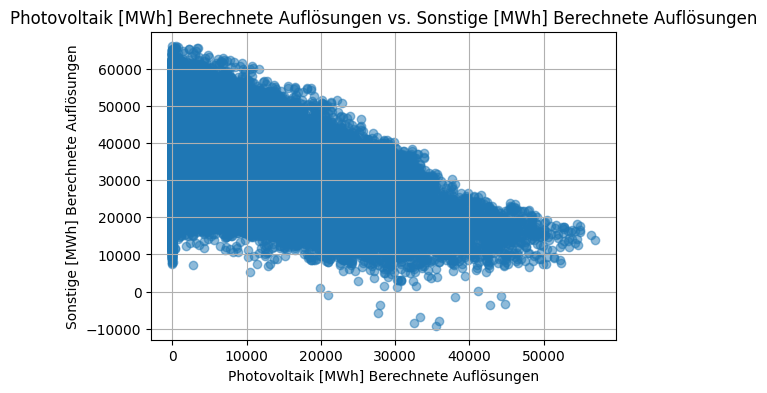

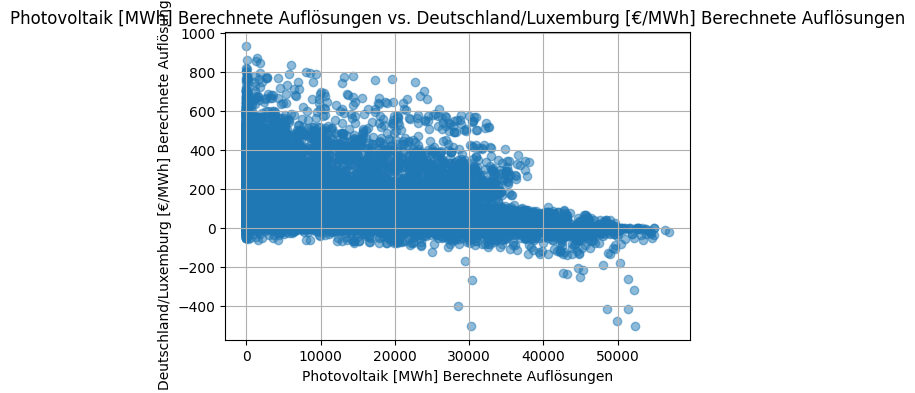

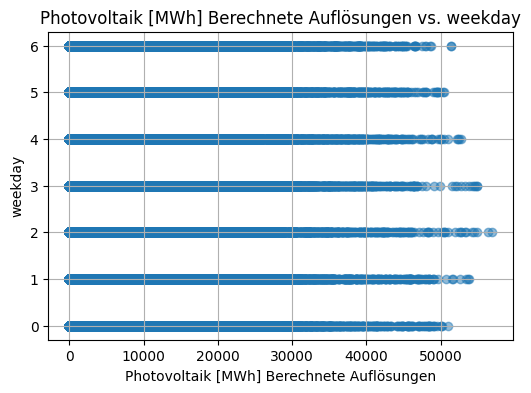

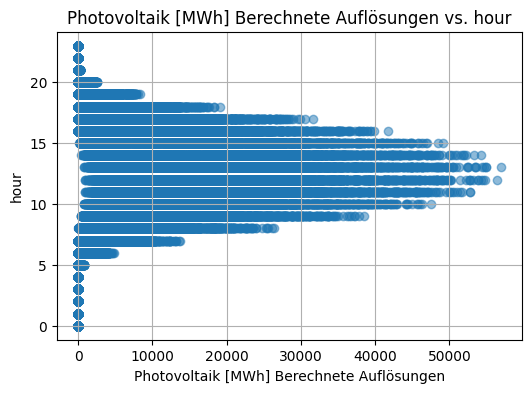

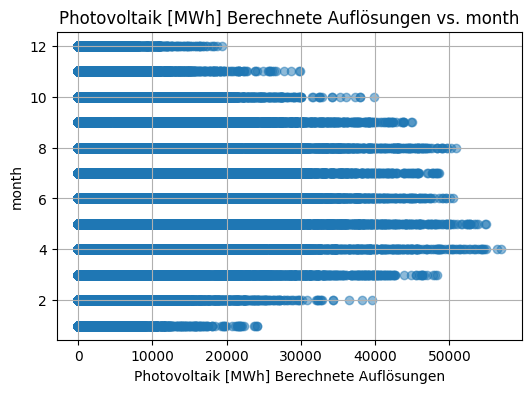

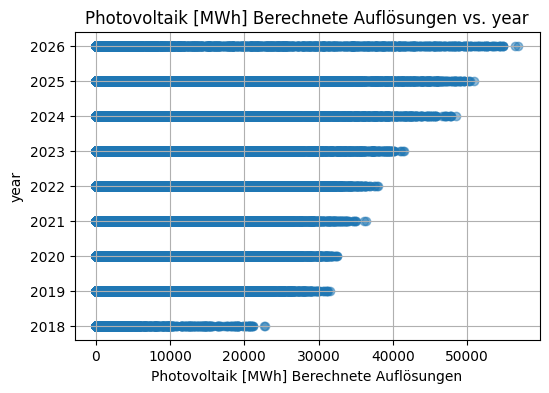

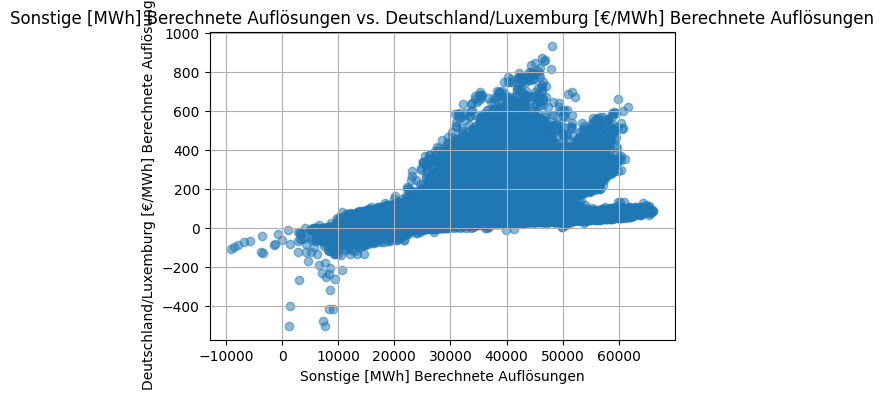

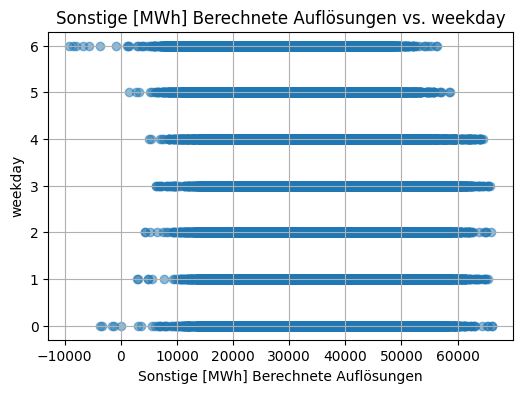

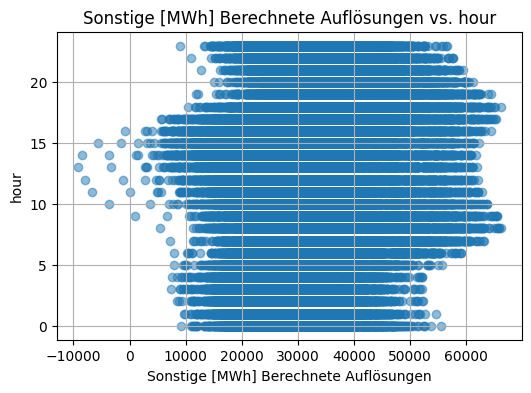

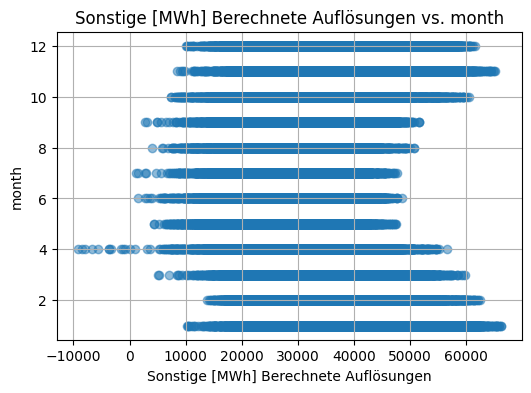

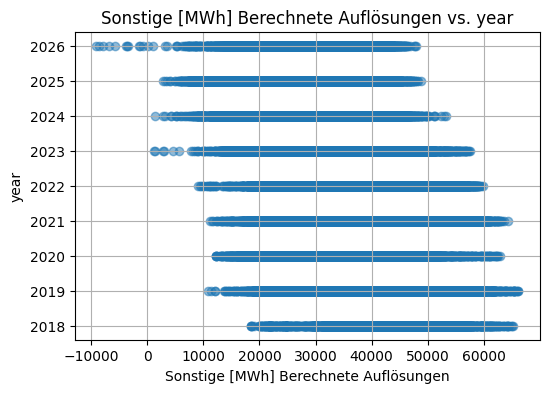

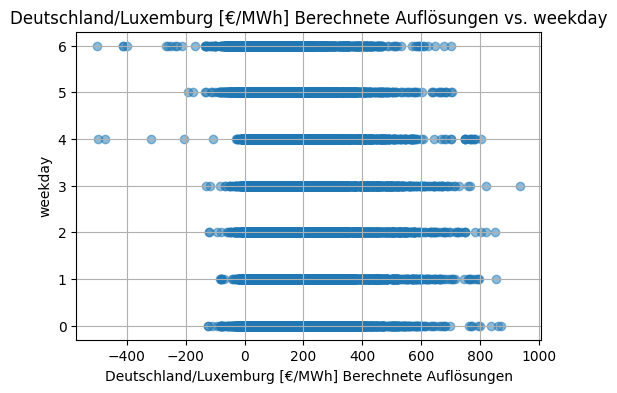

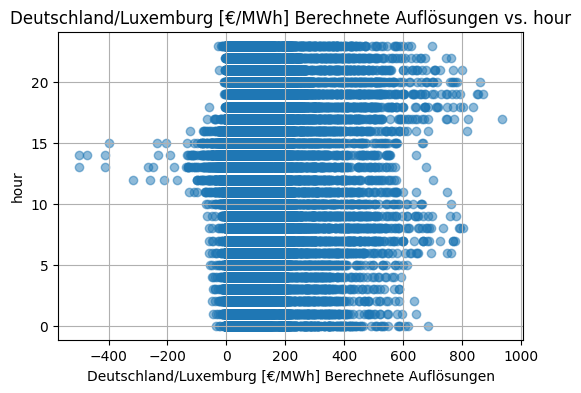

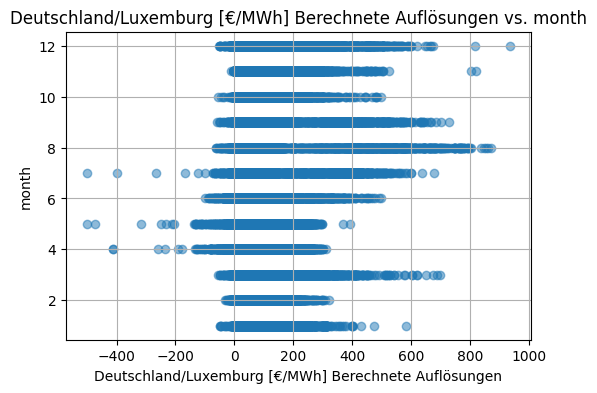

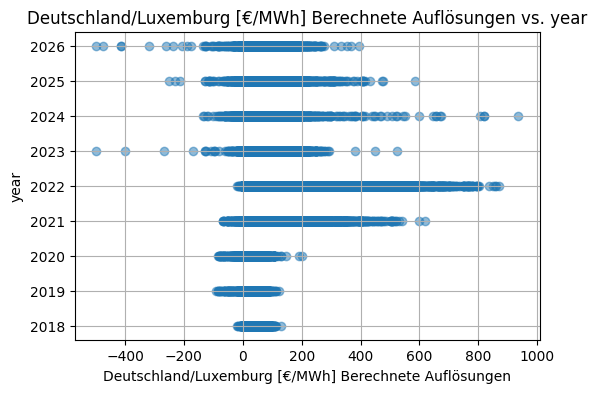

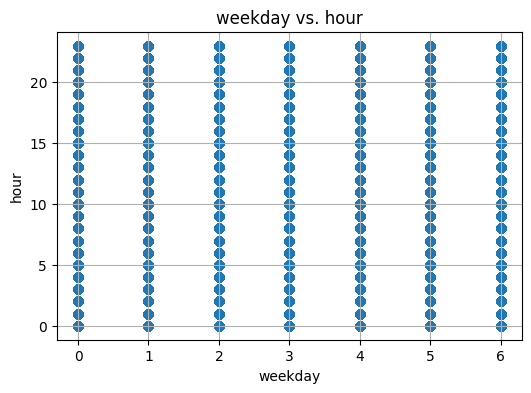

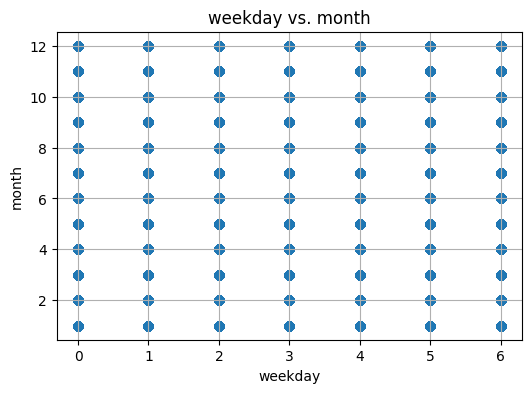

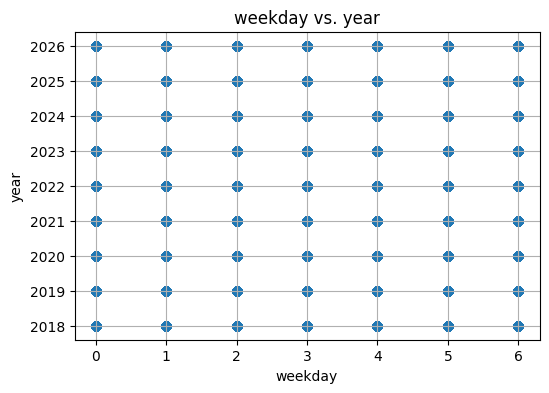

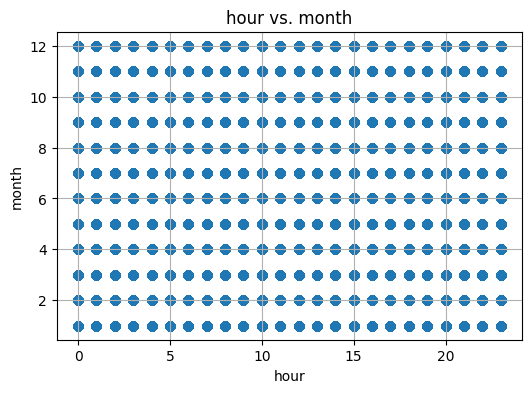

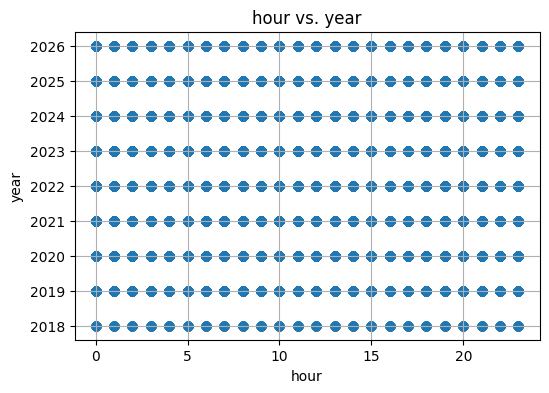

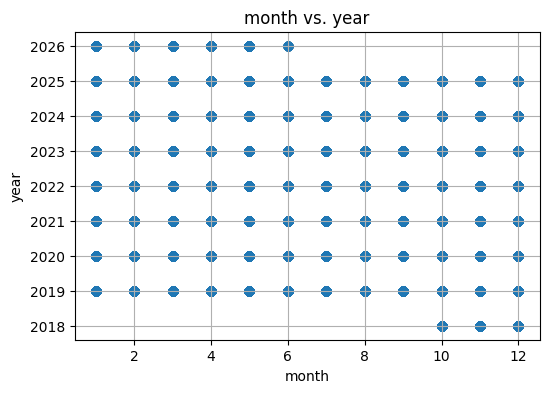

In [139]:
# Unsupervised / generative analysis
import matplotlib.pyplot as plt
from itertools import combinations

# Nur numerische Spalten auswählen
num_cols = df.select_dtypes(include="number").columns

# Alle Zweierkombinationen durchgehen
for x_col, y_col in combinations(num_cols, 2):
    plt.figure(figsize=(6, 4))
    plt.scatter(df[x_col], df[y_col], alpha=0.5)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{x_col} vs. {y_col}")
    plt.grid(True)
    plt.show()

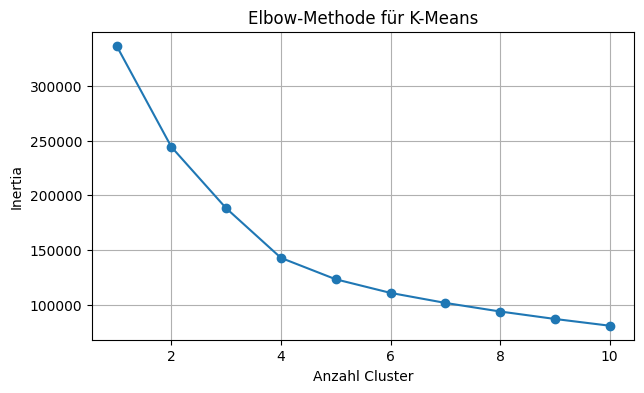

In [140]:
feature_cols = [
    'Wind Offshore [MWh] Berechnete Auflösungen',
    'Wind Onshore [MWh] Berechnete Auflösungen',
    'Photovoltaik [MWh] Berechnete Auflösungen',
    'Sonstige [MWh] Berechnete Auflösungen',
    "Netzlast [MWh] Berechnete Auflösungen",
]

df_clustering = df[feature_cols].copy()

inertias = []

cluster_range = range(1, 11)

for k in cluster_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(cluster_range, inertias, marker="o")
plt.xlabel("Anzahl Cluster")
plt.ylabel("Inertia")
plt.title("Elbow-Methode für K-Means")
plt.grid(True)
plt.show()

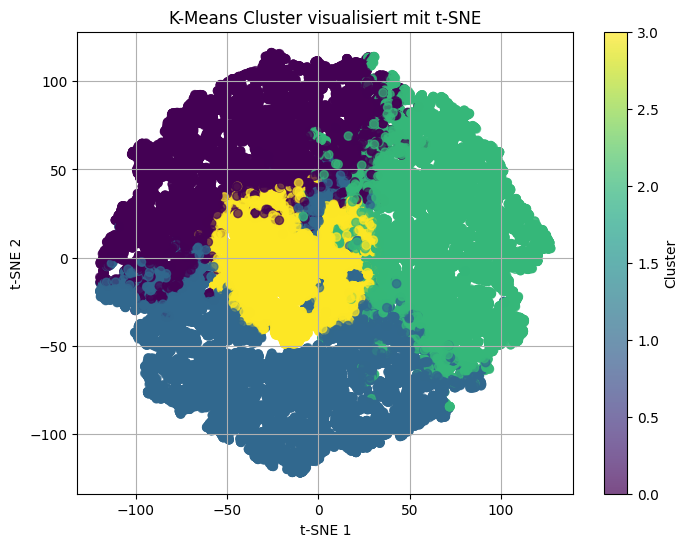

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE


# Anzahl der Cluster festlegen
n_clusters = 4

# 1. Nur numerische Features verwenden
X = df_clustering

# 2. Fehlende Werte behandeln
# Variante: fehlende Werte mit Median je Spalte auffüllen
X = X.fillna(X.median())

# 3. Features skalieren
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. K-Means anwenden
kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_scaled)

# 5. t-SNE zur 2D-Visualisierung
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

# 6. t-SNE-Ergebnisse in DataFrame speichern
df["tsne_1"] = X_tsne[:, 0]
df["tsne_2"] = X_tsne[:, 1]

# 7. Visualisierung
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    df["tsne_1"],
    df["tsne_2"],
    c=df["cluster"],
    alpha=0.7
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("K-Means Cluster visualisiert mit t-SNE")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()

In [142]:
df

,Datum von,Netzlast [MWh] Berechnete Auflösungen,Wind Offshore [MWh] Berechnete Auflösungen,Wind Onshore [MWh] Berechnete Auflösungen,Photovoltaik [MWh] Berechnete Auflösungen,Sonstige [MWh] Berechnete Auflösungen,Deutschland/Luxemburg [€/MWh] Berechnete Auflösungen,weekday,hour,month,year,German_holiday,Luxembourg_holiday,cluster,tsne_1,tsne_2
0,2018-10-01 00:00:00,44178.003337,1617.25,4242.00,0.00,38690.75,59.53,0,0,10,2018,False,False,1,-65.377823,-56.652138
1,2018-10-01 01:00:00,43768.925821,1657.50,4096.50,0.00,37707.00,56.10,0,1,10,2018,False,False,1,-64.614861,-56.904686
2,2018-10-01 02:00:00,42628.000000,1750.50,4152.00,0.00,37311.50,51.41,0,2,10,2018,False,False,1,-63.891827,-56.696133
3,2018-10-01 03:00:00,42986.750000,1895.25,4436.25,0.00,36318.50,47.38,0,3,10,2018,False,False,1,-63.739040,-56.435764
4,2018-10-01 04:00:00,44675.000000,2138.25,4816.25,0.00,37481.50,47.59,0,4,10,2018,False,False,1,-66.612785,-47.642567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67291,2026-06-04 19:00:00,52194.280000,4978.72,22366.01,3950.46,25564.73,114.17,3,19,6,2026,False,False,2,54.900852,7.384235
67292,2026-06-04 20:00:00,51930.650000,5167.91,21943.25,1137.85,25791.74,117.96,3,20,6,2026,False,False,2,65.882408,-1.658486
67293,2026-06-04 21:00:00,50551.840000,5451.33,22037.07,104.24,25573.48,115.37,3,21,6,2026,False,False,2,74.138901,-4.860115
67294,2026-06-04 22:00:00,48818.860000,5682.32,22200.84,0.00,23723.35,111.69,3,22,6,2026,False,False,2,83.503578,-21.242687


In [143]:
# Numerische Spalten auswählen
num_cols = df.select_dtypes(include="number").columns

# Spalten ausschließen, die keine ursprünglichen Features sind
exclude_cols = ["cluster", "tsne_1", "tsne_2"]
feature_cols = [col for col in num_cols if col not in exclude_cols]

# Mittelwerte je Cluster berechnen
cluster_means = df.groupby("cluster")[feature_cols].mean()

cluster_means

,Netzlast [MWh] Berechnete Auflösungen,Wind Offshore [MWh] Berechnete Auflösungen,Wind Onshore [MWh] Berechnete Auflösungen,Photovoltaik [MWh] Berechnete Auflösungen,Sonstige [MWh] Berechnete Auflösungen,Deutschland/Luxemburg [€/MWh] Berechnete Auflösungen,weekday,hour,month,year
cluster,,,,,,,,,,
0,62615.882078,2350.565317,7749.794008,3881.517717,44403.861847,134.961873,2.274915,13.949943,6.587826,2021.249943
1,45833.057958,1911.595290,7433.087491,1182.724838,29803.571956,98.694340,3.521020,8.696397,6.762690,2022.165105
2,55266.783903,5024.792737,23721.445450,2801.863061,27291.457999,62.704156,3.081421,11.438437,6.257484,2022.378890
3,58173.508862,1939.469387,7048.638641,25141.010655,24305.011565,69.653404,3.067558,12.749187,6.170430,2022.808255


/var/folders/j7/61_hz7955mn3z2j247bwq_m00000gn/T/ipykernel_28931/1056640706.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=clusters)


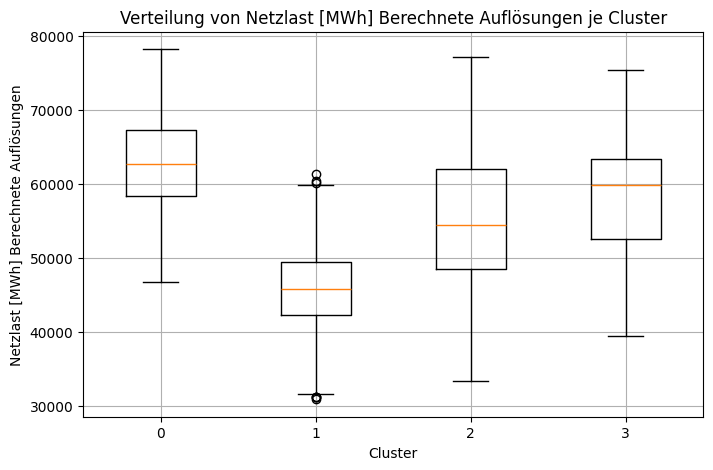

/var/folders/j7/61_hz7955mn3z2j247bwq_m00000gn/T/ipykernel_28931/1056640706.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=clusters)


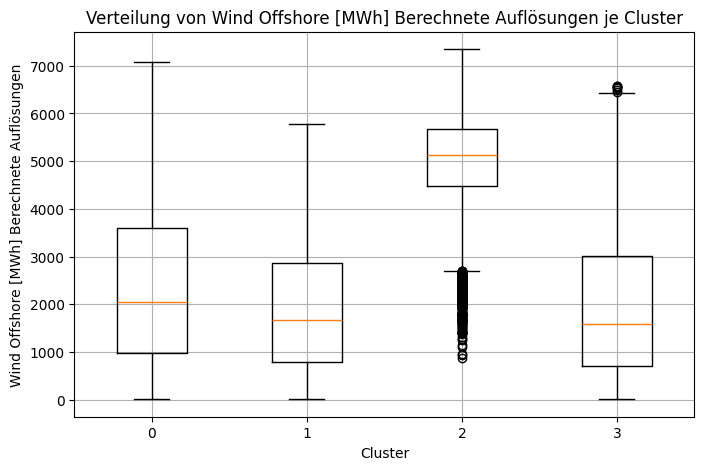

/var/folders/j7/61_hz7955mn3z2j247bwq_m00000gn/T/ipykernel_28931/1056640706.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=clusters)


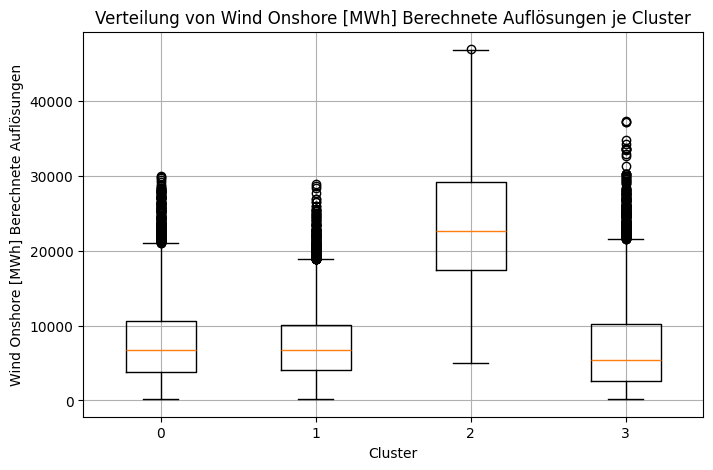

/var/folders/j7/61_hz7955mn3z2j247bwq_m00000gn/T/ipykernel_28931/1056640706.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=clusters)


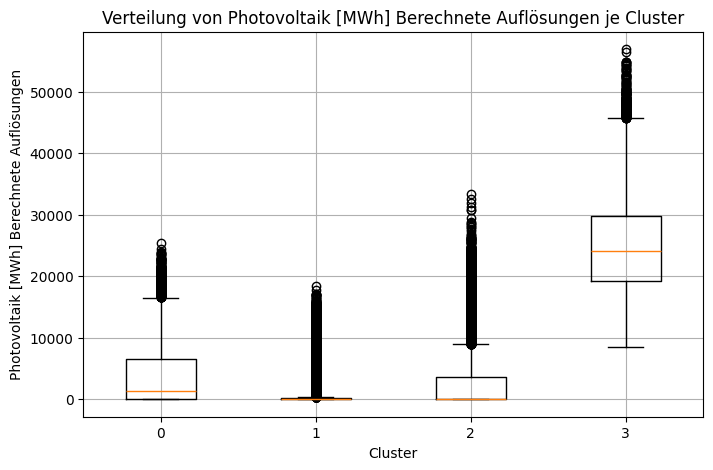

/var/folders/j7/61_hz7955mn3z2j247bwq_m00000gn/T/ipykernel_28931/1056640706.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=clusters)


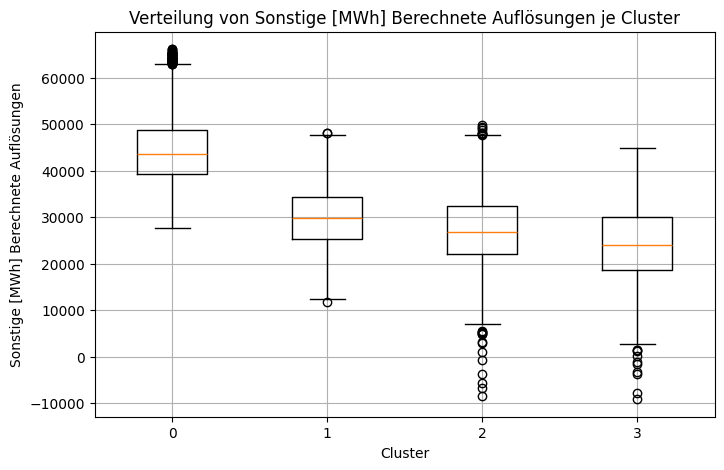

/var/folders/j7/61_hz7955mn3z2j247bwq_m00000gn/T/ipykernel_28931/1056640706.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=clusters)


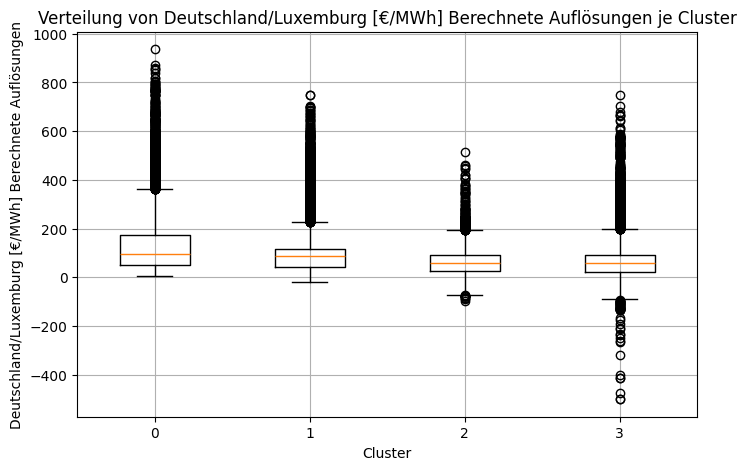

/var/folders/j7/61_hz7955mn3z2j247bwq_m00000gn/T/ipykernel_28931/1056640706.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=clusters)


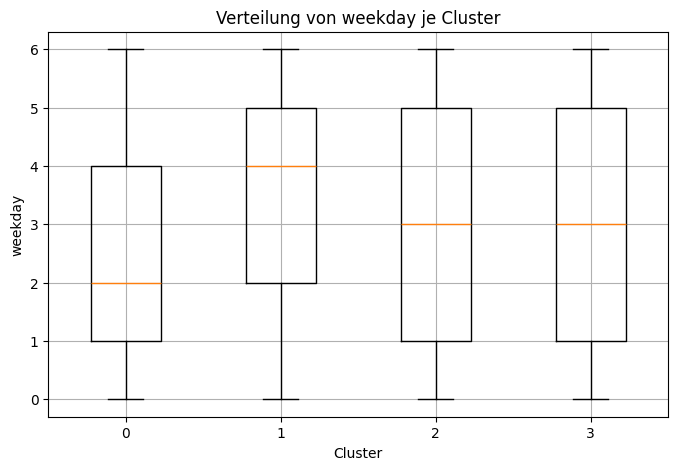

/var/folders/j7/61_hz7955mn3z2j247bwq_m00000gn/T/ipykernel_28931/1056640706.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=clusters)


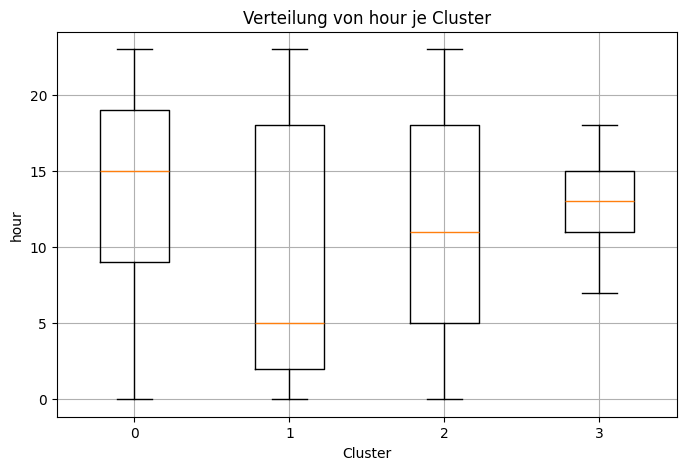

/var/folders/j7/61_hz7955mn3z2j247bwq_m00000gn/T/ipykernel_28931/1056640706.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=clusters)


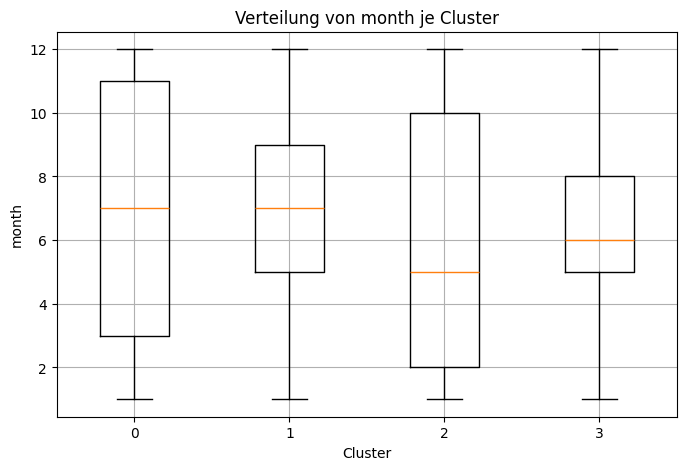

/var/folders/j7/61_hz7955mn3z2j247bwq_m00000gn/T/ipykernel_28931/1056640706.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=clusters)


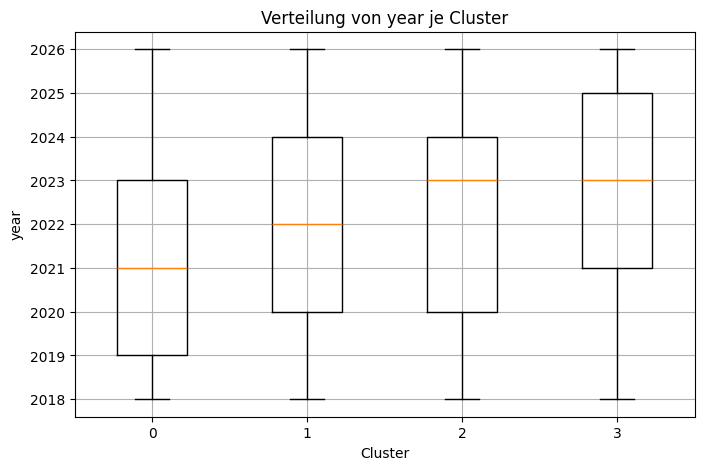

In [144]:
import matplotlib.pyplot as plt

# Numerische Spalten auswählen
num_cols = df.select_dtypes(include="number").columns

# Hilfsspalten ausschließen
exclude_cols = ["cluster", "tsne_1", "tsne_2"]
feature_cols = [col for col in num_cols if col not in exclude_cols]

# Sicherstellen, dass Cluster-Spalte existiert
clusters = sorted(df["cluster"].dropna().unique())

# Für jede Dimension einen Boxplot nach Cluster erstellen
for feature in feature_cols:
    data = [
        df.loc[df["cluster"] == cluster, feature].dropna()
        for cluster in clusters
    ]

    plt.figure(figsize=(8, 5))
    plt.boxplot(data, labels=clusters)

    plt.xlabel("Cluster")
    plt.ylabel(feature)
    plt.title(f"Verteilung von {feature} je Cluster")
    plt.grid(True)
    plt.show()

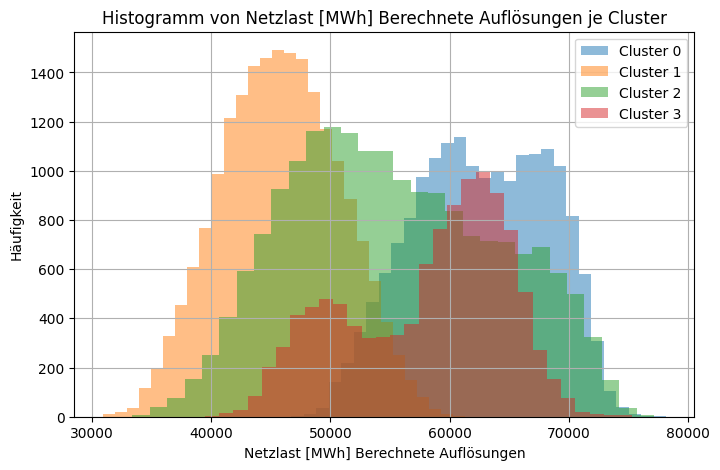

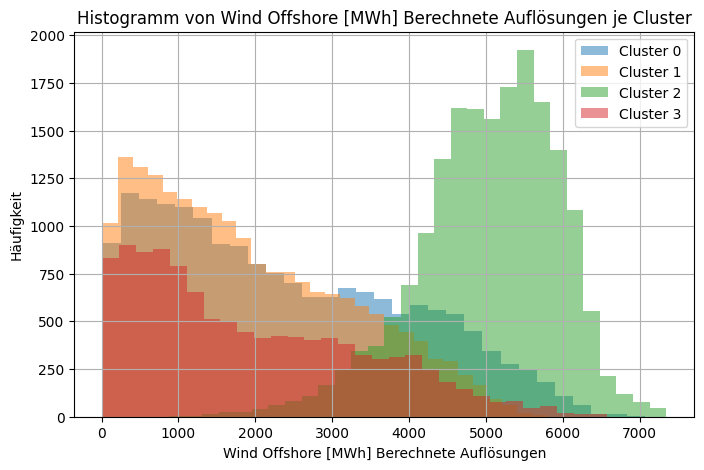

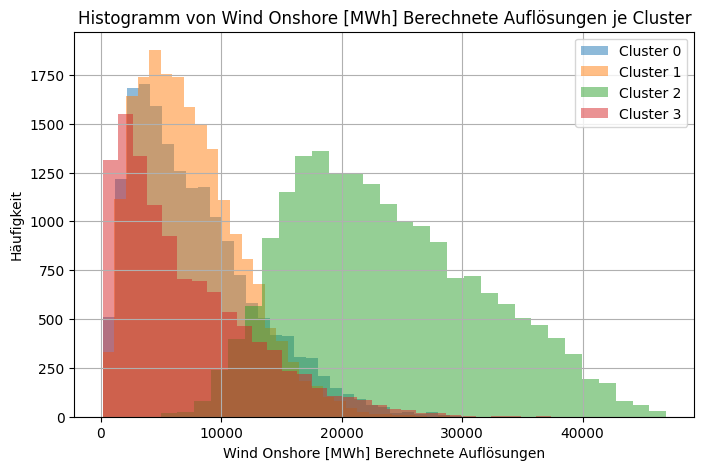

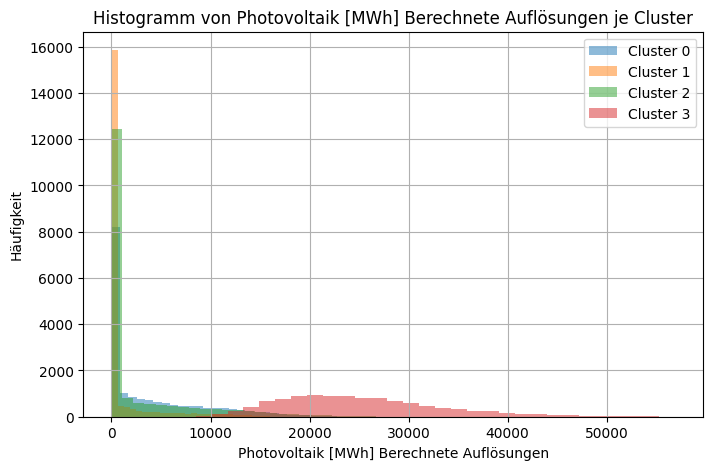

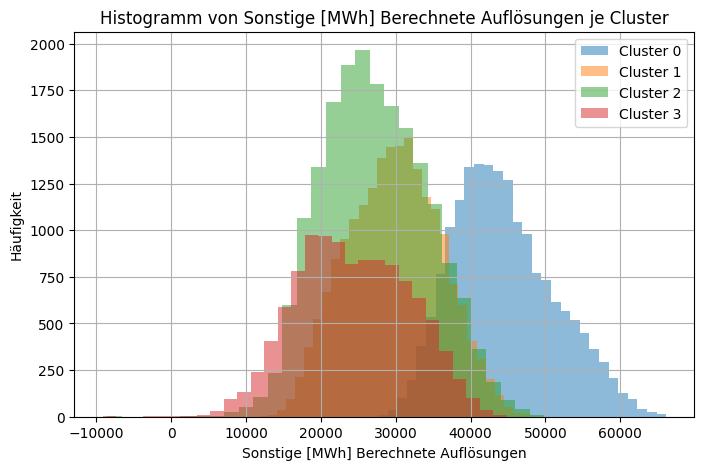

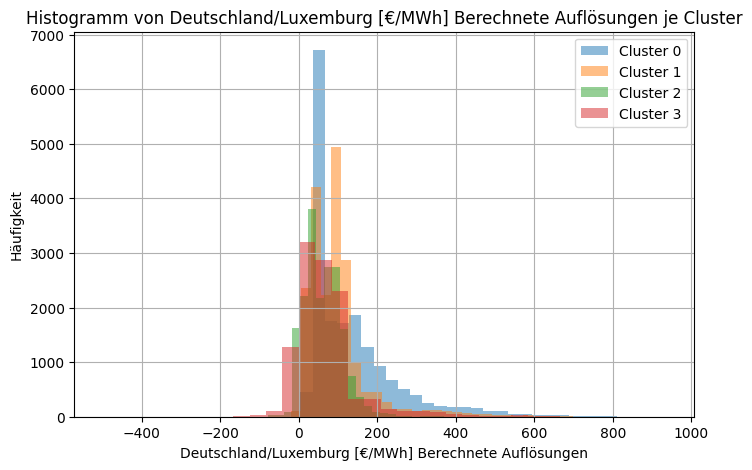

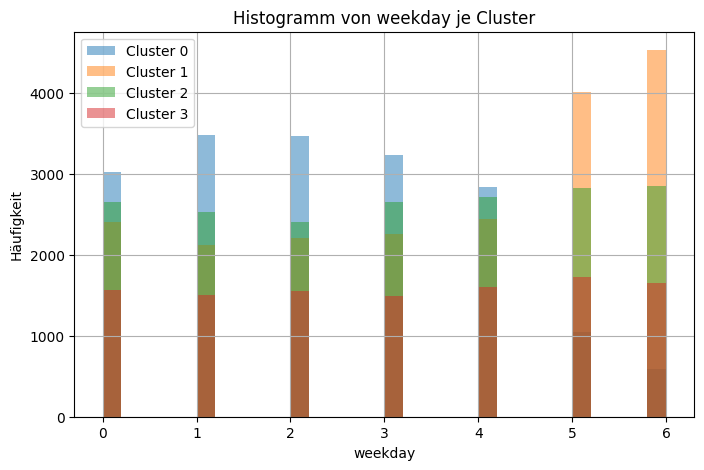

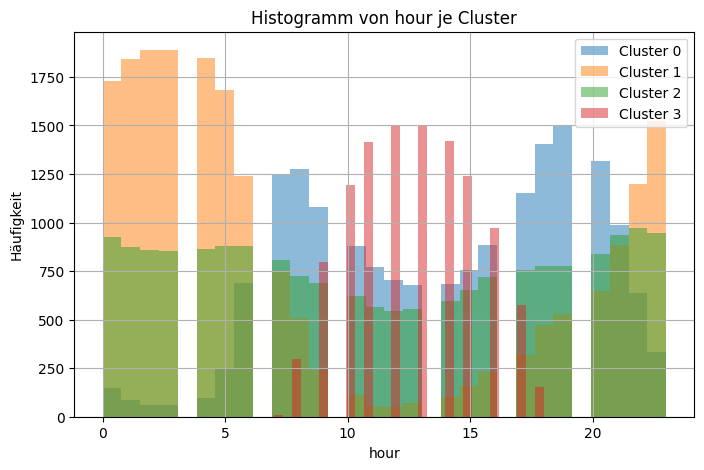

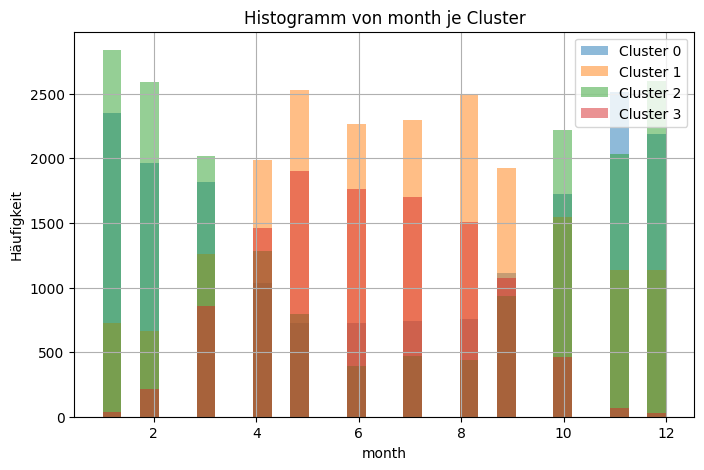

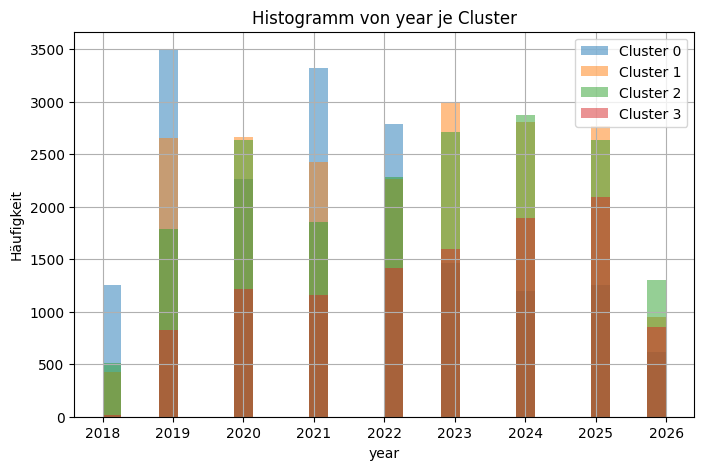

In [145]:
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include="number").columns

exclude_cols = ["cluster", "tsne_1", "tsne_2"]
feature_cols = [col for col in num_cols if col not in exclude_cols]

clusters = sorted(df["cluster"].dropna().unique())

for feature in feature_cols:
    plt.figure(figsize=(8, 5))

    for cluster in clusters:
        values = df.loc[df["cluster"] == cluster, feature].dropna()

        plt.hist(
            values,
            bins=30,
            alpha=0.5,
            label=f"Cluster {cluster}"
        )

    plt.xlabel(feature)
    plt.ylabel("Häufigkeit")
    plt.title(f"Histogramm von {feature} je Cluster")
    plt.legend()
    plt.grid(True)
    plt.show()

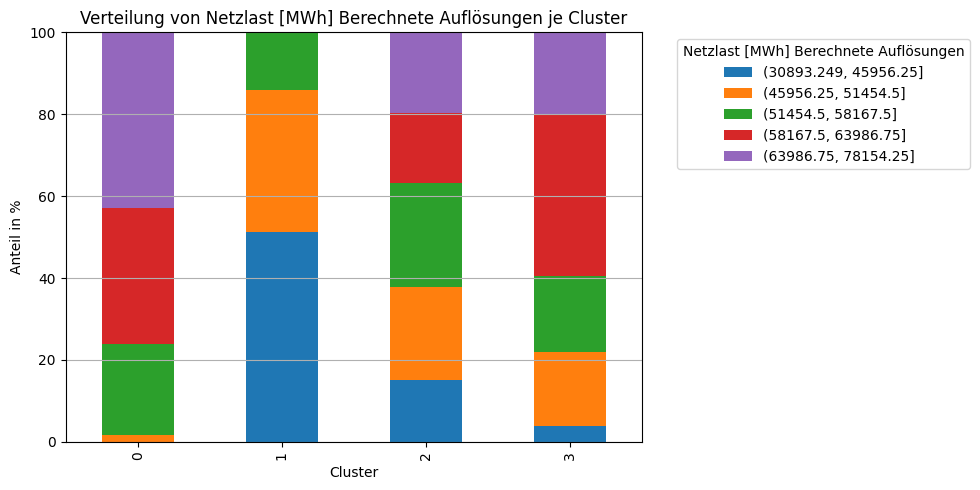

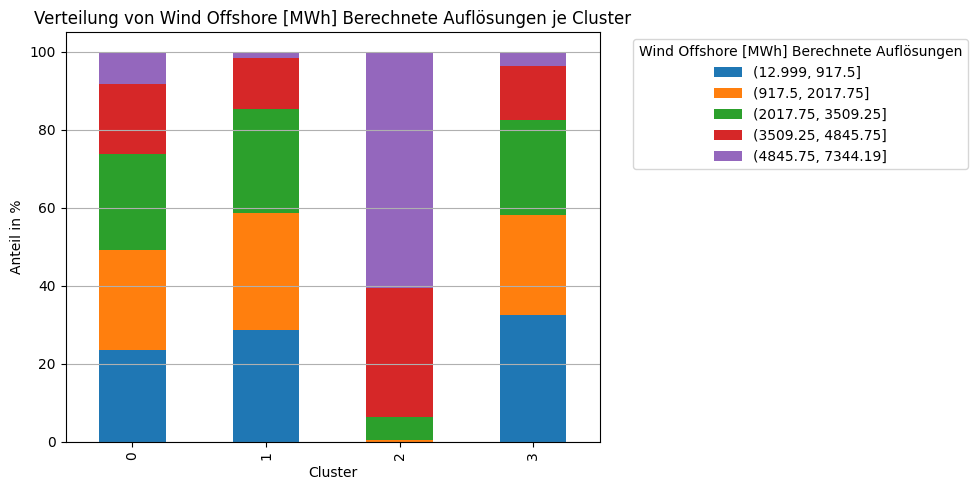

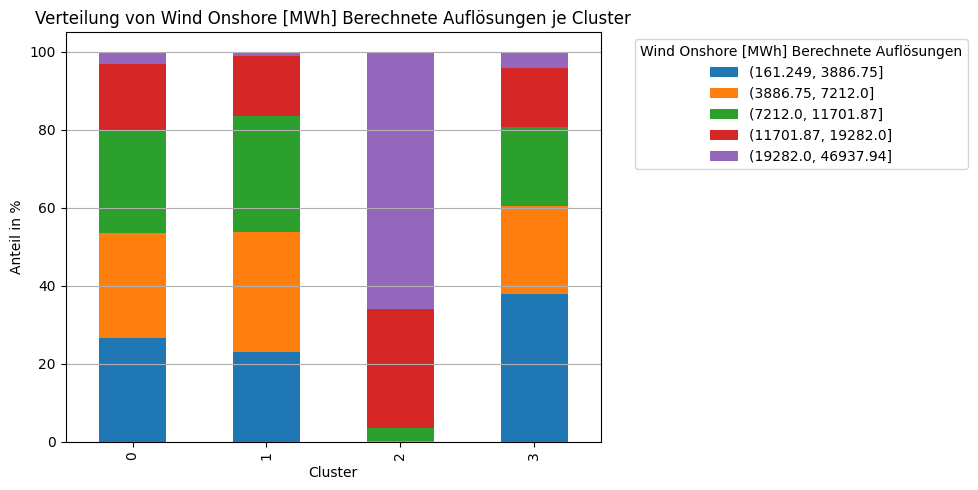

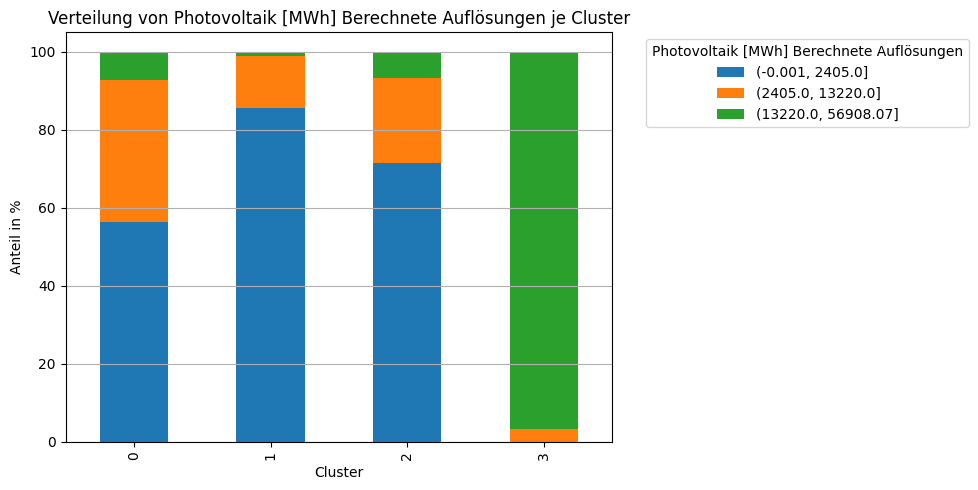

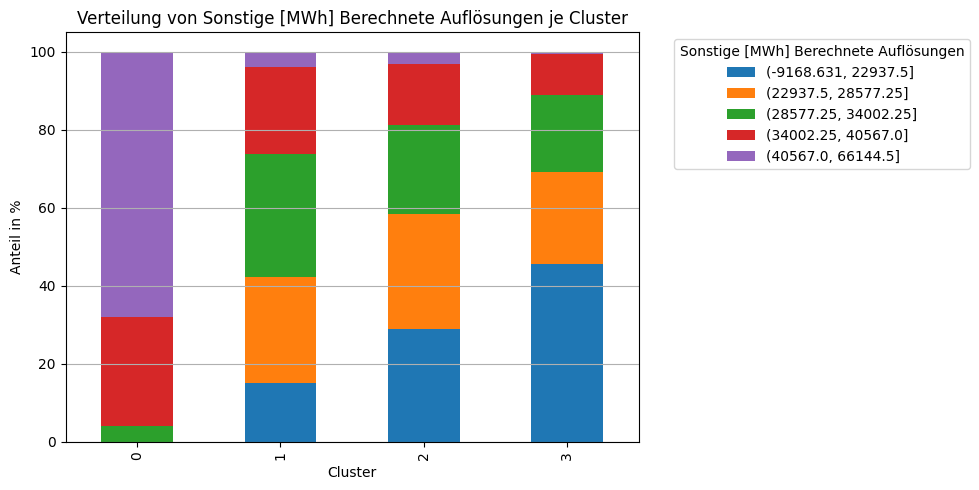

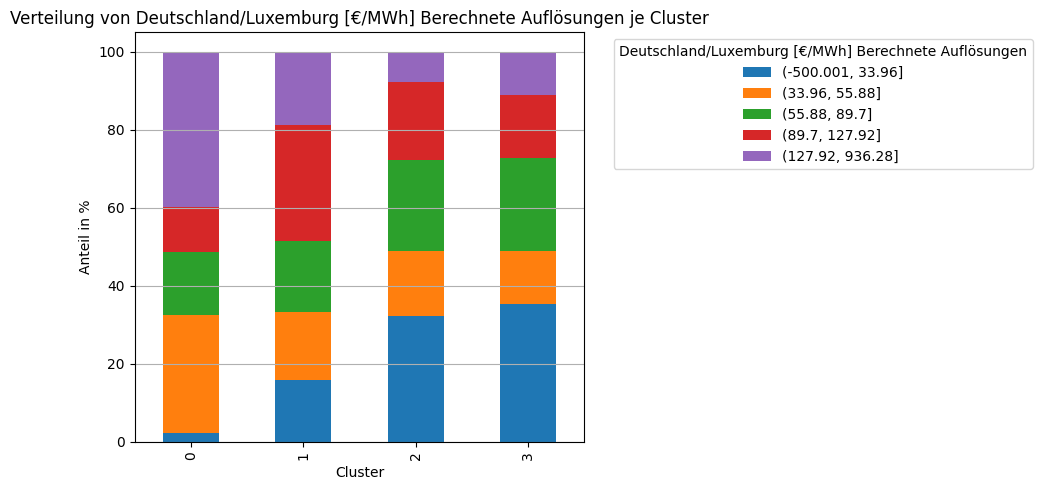

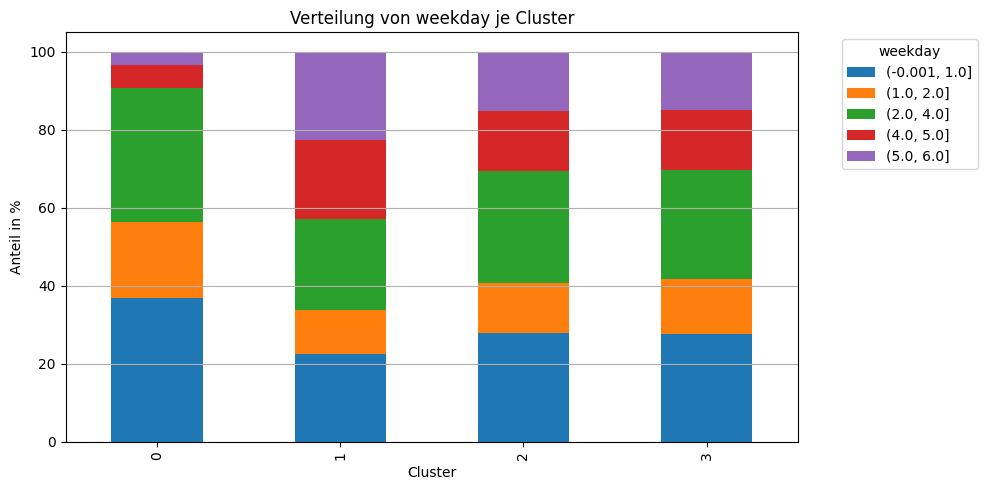

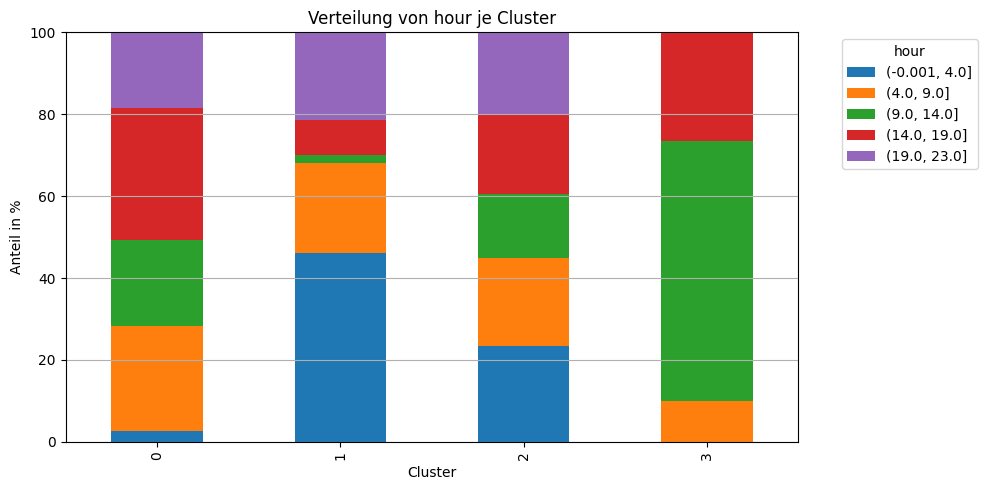

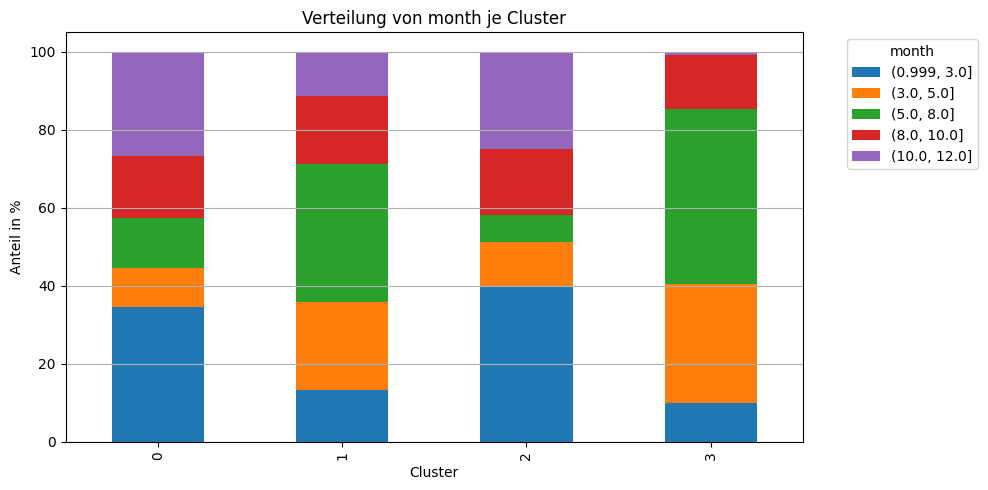

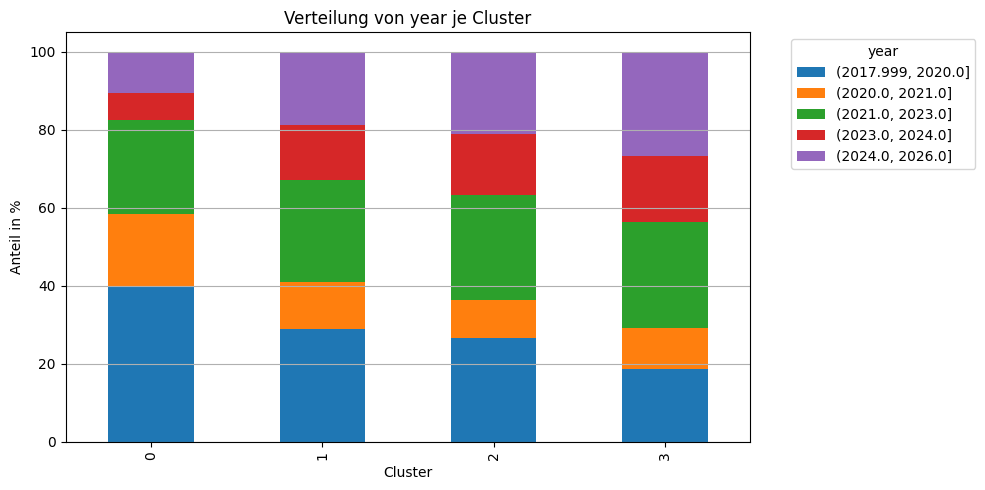

In [146]:
import pandas as pd
import matplotlib.pyplot as plt

# Numerische Features auswählen
num_cols = df.select_dtypes(include="number").columns

# Hilfsspalten ausschließen
exclude_cols = ["cluster", "tsne_1", "tsne_2"]
feature_cols = [col for col in num_cols if col not in exclude_cols]

# Anzahl der Werteklassen je Feature
n_bins = 5

for feature in feature_cols:
    
    temp = df[[feature, "cluster"]].dropna().copy()
    
    # Feature in Quantile einteilen
    temp["bin"] = pd.qcut(
        temp[feature],
        q=n_bins,
        duplicates="drop"
    )
    
    # Anteil je Cluster und Bin berechnen
    plot_data = pd.crosstab(
        temp["cluster"],
        temp["bin"],
        normalize="index"
    ) * 100
    
    # Gestapeltes Balkendiagramm
    plot_data.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 5)
    )
    
    plt.xlabel("Cluster")
    plt.ylabel("Anteil in %")
    plt.title(f"Verteilung von {feature} je Cluster")
    plt.legend(title=feature, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()

## 8. Discussion & Conclusion *(complete for final submission)*

*Synthesise findings across all three method blocks. What does each lens reveal that the others miss? What are the limitations of your analysis?*
